# Student Habits & Academic Performance -- Advanced ML Pipeline
## End-to-End: EDA -> Feature Engineering -> ML/DL -> XAI (SHAP) -> Export

**Pipeline Phases:**
1. Environment Setup & Data Ingestion
2. Advanced EDA with Annotated Visuals
3. Advanced Feature Engineering
4. Baseline ML Framework
5. Advanced ML Framework -- Tuning, Regularization, Stacking
6. Ultra-Advanced DL Framework -- Multi-architecture Comparison
7. Model Orchestration & Full Comparison
8. XAI -- SHAP, Permutation Importance, PDP
9. Export All Outputs -> ZIP Download


## Phase 1 -- Environment Setup & Data Ingestion

In [1]:
# Phase 1.1 -- Install / upgrade packages
import subprocess, sys

def pip(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

for pkg in ["shap", "catboost", "lightgbm", "optuna", "scikit-learn"]:
    pip(pkg)

print("All packages ready.")


All packages ready.


In [2]:
# Phase 1.2 -- Core imports
import os, warnings, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, shapiro, levene
from itertools import combinations
from sklearn.covariance import MinCovDet

# Preprocessing
from sklearn.model_selection import (train_test_split, cross_val_score, KFold,
                                      GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import (StandardScaler, RobustScaler,
                                    LabelEncoder, QuantileTransformer)
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import mutual_info_regression

# Baseline models
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet,
                                   BayesianRidge, HuberRegressor, RidgeCV, LassoCV)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, VotingRegressor,
                               StackingRegressor)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import (mean_squared_error, mean_absolute_error, r2_score,
                              mean_absolute_percentage_error)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Advanced boosters
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# Hyperparameter optimisation
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, regularizers, callbacks, optimizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import Input as KInput

# XAI
import shap

warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

# Output directories
OUT = Path("output_artifacts")
OUT.mkdir(exist_ok=True)
for sub in ["eda", "features", "models", "xai"]:
    (OUT / sub).mkdir(exist_ok=True)

def savefig(name: str, subdir: str = "eda"):
    path = OUT / subdir / f"{name}.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"  saved -> {path}")

print("Imports complete. Output dirs created.")
print(f"  TensorFlow {tf.__version__}  |  XGBoost {xgb.__version__}  |  LightGBM {lgb.__version__}")


Imports complete. Output dirs created.
  TensorFlow 2.20.0  |  XGBoost 3.2.0  |  LightGBM 4.6.0


In [3]:
# Phase 1.3 -- Data ingestion: upload CSV from local machine
from google.colab import files

print("Please upload student_habits_performance.csv when prompted:")
uploaded = files.upload()

csv_name = [k for k in uploaded.keys() if k.endswith(".csv")][0]
df_raw = pd.read_csv(csv_name)
df = df_raw.copy()

print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("Column overview:")
print(df.dtypes.to_string())


Please upload student_habits_performance.csv when prompted:


Saving student_habits_performance.csv to student_habits_performance.csv
Loaded 1,000 rows x 16 columns
Column overview:
student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score                       float64


---
## Phase 2 -- Advanced Exploratory Data Analysis

Each subsection prints a plain-English interpretation directly beneath its visual.


In [4]:
# Phase 2.1 -- Dataset snapshot & quality report
print("=" * 60)
print("DATASET QUALITY REPORT")
print("=" * 60)
print(f"Shape          : {df.shape}")
print(f"Duplicate rows : {df.duplicated().sum()}")
print(f"Missing values : {df.isnull().sum().sum()}")
print()
print(df.describe(include="all").T.to_string())

# Drop duplicates & NAs
df = df.drop_duplicates().dropna()
print(f"After cleaning: {df.shape[0]:,} rows remain.")


DATASET QUALITY REPORT
Shape          : (1000, 16)
Duplicate rows : 0
Missing values : 91

                                count unique          top freq     mean        std   min     25%   50%     75%    max
student_id                       1000   1000        S1999    1      NaN        NaN   NaN     NaN   NaN     NaN    NaN
age                            1000.0    NaN          NaN  NaN   20.498     2.3081  17.0   18.75  20.0    23.0   24.0
gender                           1000      3       Female  481      NaN        NaN   NaN     NaN   NaN     NaN    NaN
study_hours_per_day            1000.0    NaN          NaN  NaN   3.5501    1.46889   0.0     2.6   3.5     4.5    8.3
social_media_hours             1000.0    NaN          NaN  NaN   2.5055   1.172422   0.0     1.7   2.5     3.3    7.2
netflix_hours                  1000.0    NaN          NaN  NaN   1.8197   1.075118   0.0     1.0   1.8   2.525    5.4
part_time_job                    1000      2           No  785      NaN        NaN 

In [5]:
# Phase 2.2 -- Define column groups
NUM_COLS = ["age", "study_hours_per_day", "social_media_hours",
            "netflix_hours", "attendance_percentage", "sleep_hours",
            "exercise_frequency", "mental_health_rating", "exam_score"]

CAT_COLS = ["gender", "part_time_job", "diet_quality",
            "parental_education_level", "internet_quality",
            "extracurricular_participation"]

TARGET = "exam_score"
print(f"Numerical  ({len(NUM_COLS)}): {NUM_COLS}")
print(f"Categorical({len(CAT_COLS)}): {CAT_COLS}")


Numerical  (9): ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']
Categorical(6): ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


  saved -> output_artifacts/eda/numeric_distributions.png


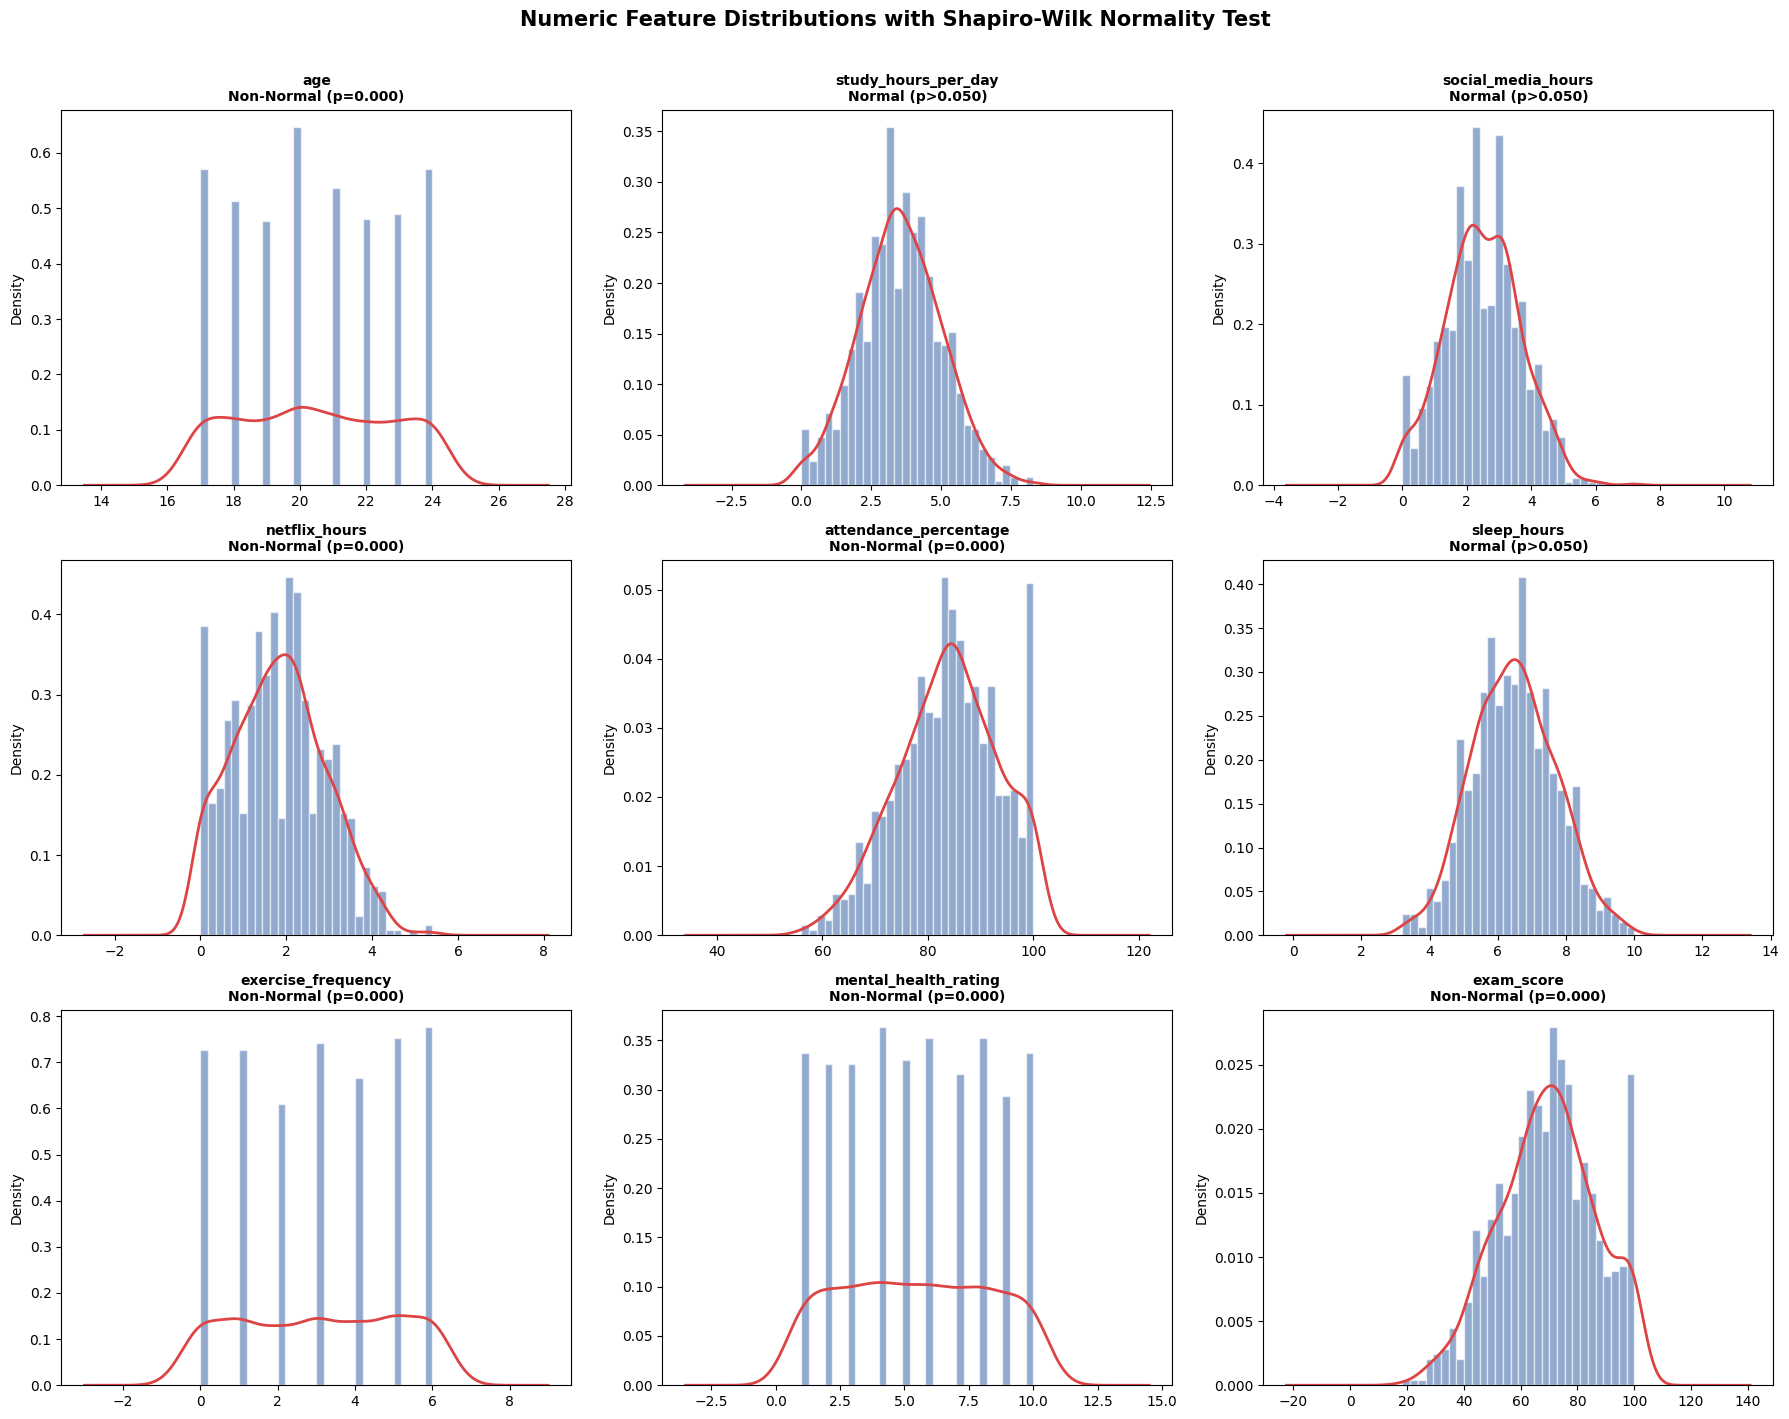


INTERPRETATION:
  - Normal columns can be used safely with parametric models.
  - Non-normal features may benefit from log/quantile transformation.
  - exam_score shape reveals whether the prediction task is balanced or skewed.



In [6]:
# Phase 2.3 -- Numeric distributions: histogram + KDE + Shapiro-Wilk normality test
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=30, color="#4C72B0", alpha=0.6, density=True, edgecolor="white")
    data.plot.kde(ax=ax, color="#DD4444", lw=2)
    stat, p = shapiro(data[:500])
    normal = "Normal (p>{:.3f})".format(0.05) if p > 0.05 else "Non-Normal (p={:.3f})".format(p)
    ax.set_title(f"{col}\n{normal}", fontsize=10, fontweight="bold")

plt.suptitle("Numeric Feature Distributions with Shapiro-Wilk Normality Test",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
savefig("numeric_distributions", "eda")
plt.show()

print("""
INTERPRETATION:
  - Normal columns can be used safely with parametric models.
  - Non-normal features may benefit from log/quantile transformation.
  - exam_score shape reveals whether the prediction task is balanced or skewed.
""")


  saved -> output_artifacts/eda/correlation_heatmap.png


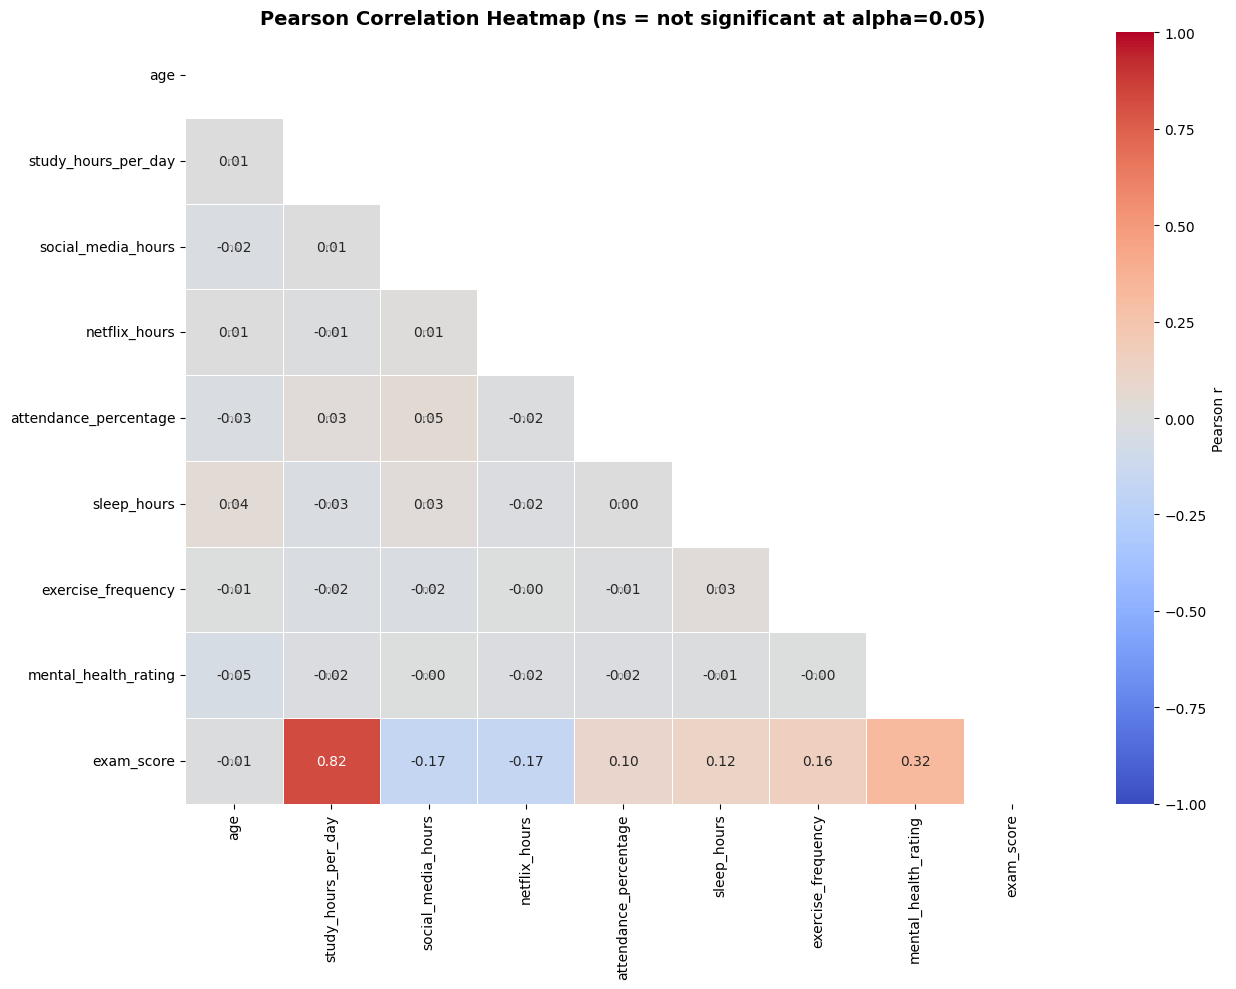

Top 5 features correlated with exam_score:
study_hours_per_day     0.822950
mental_health_rating    0.317945
social_media_hours      0.171672
netflix_hours           0.166578
exercise_frequency      0.161397

INTERPRETATION:
  - Darker red = strong positive correlation; darker blue = strong negative.
  - ns marks cell pairs not statistically significant.
  - study_hours_per_day typically shows the strongest positive relationship.



In [7]:
# Phase 2.4 -- Annotated Pearson Correlation Heatmap with p-value significance mask
corr_mat = df[NUM_COLS].corr()
pval_mat = pd.DataFrame(np.ones_like(corr_mat), columns=NUM_COLS, index=NUM_COLS)

for c1, c2 in combinations(NUM_COLS, 2):
    _, p = pearsonr(df[c1].dropna(), df[c2].dropna())
    pval_mat.loc[c1, c2] = p
    pval_mat.loc[c2, c1] = p

mask_upper = np.triu(np.ones_like(corr_mat, dtype=bool))
insig_mask = (pval_mat > 0.05)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(corr_mat, mask=mask_upper, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=.5,
            cbar_kws={"label": "Pearson r"}, ax=ax, vmin=-1, vmax=1)

for (r, c) in np.argwhere(~mask_upper & insig_mask.values):
    ax.text(c + 0.5, r + 0.5, "ns", ha="center", va="center",
            fontsize=8, color="grey", alpha=0.7)

ax.set_title("Pearson Correlation Heatmap (ns = not significant at alpha=0.05)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
savefig("correlation_heatmap", "eda")
plt.show()

top_corr = corr_mat[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print("Top 5 features correlated with exam_score:")
print(top_corr.head(5).to_string())
print("""
INTERPRETATION:
  - Darker red = strong positive correlation; darker blue = strong negative.
  - ns marks cell pairs not statistically significant.
  - study_hours_per_day typically shows the strongest positive relationship.
""")


  saved -> output_artifacts/eda/pairplot_top4.png


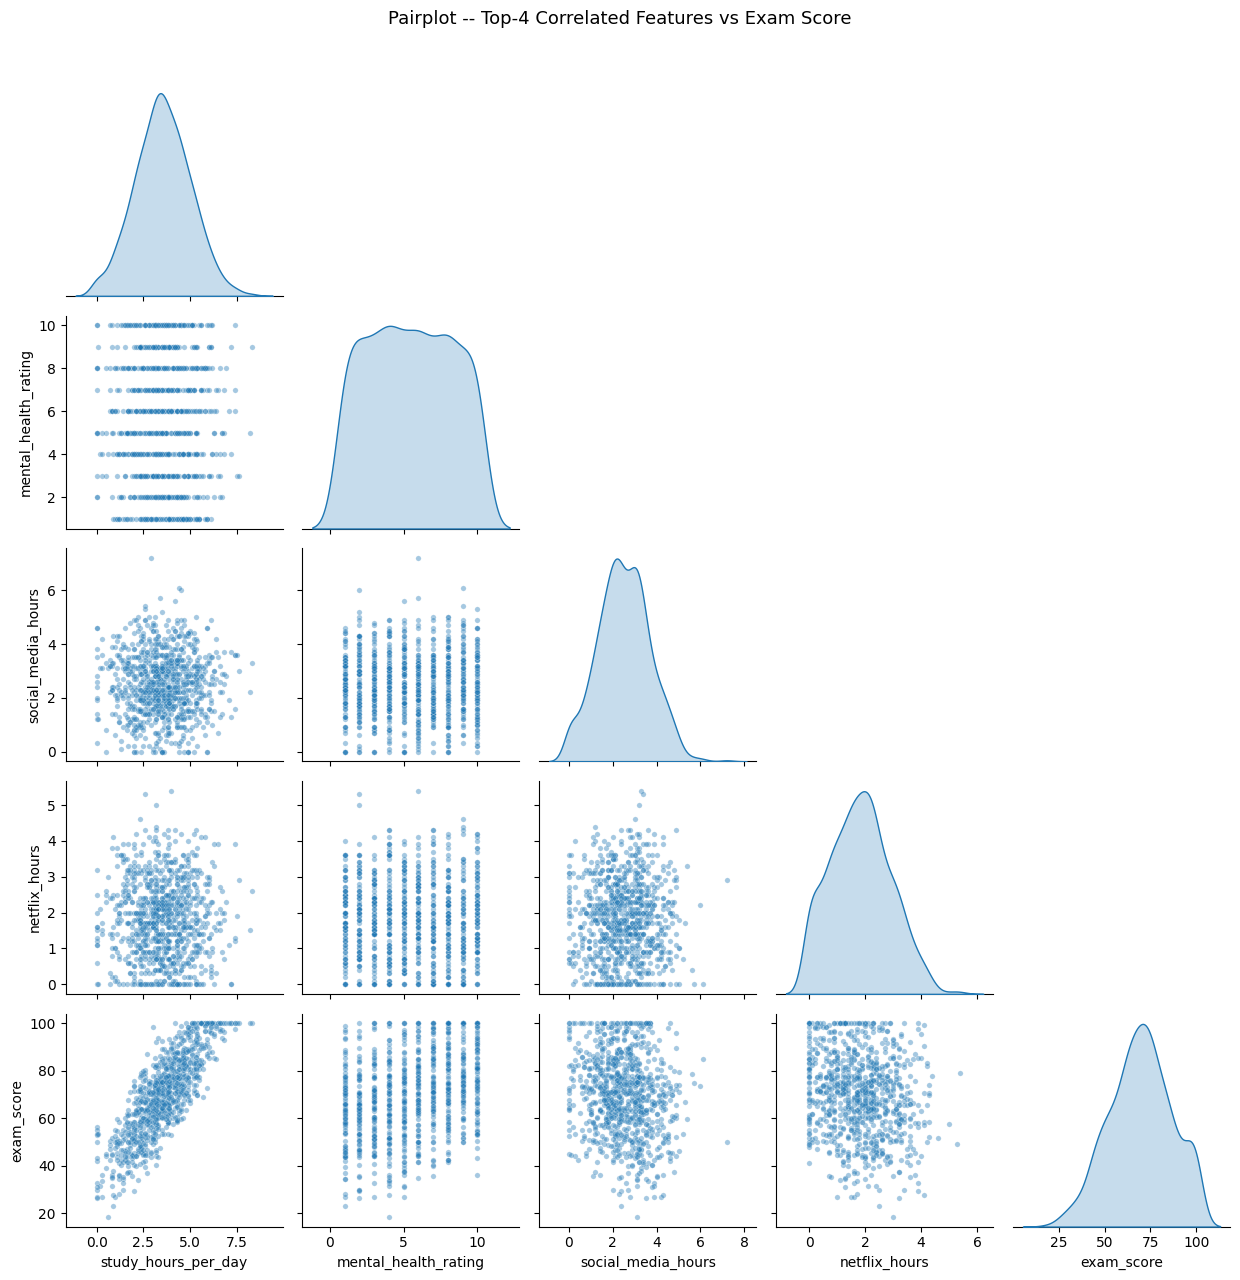

Diagonal = individual KDE; off-diagonal = scatter of each pair.


In [8]:
# Phase 2.5 -- Pairplot of top-4 numeric features vs target
top4 = top_corr.head(4).index.tolist() + [TARGET]
g = sns.pairplot(df[top4], corner=True, plot_kws={"alpha": 0.4, "s": 15},
                 diag_kind="kde", diag_kws={"fill": True})
g.fig.suptitle("Pairplot -- Top-4 Correlated Features vs Exam Score", y=1.02, fontsize=13)
g.fig.tight_layout()
savefig("pairplot_top4", "eda")
plt.show()
print("Diagonal = individual KDE; off-diagonal = scatter of each pair.")


  saved -> output_artifacts/eda/categorical_boxplots.png


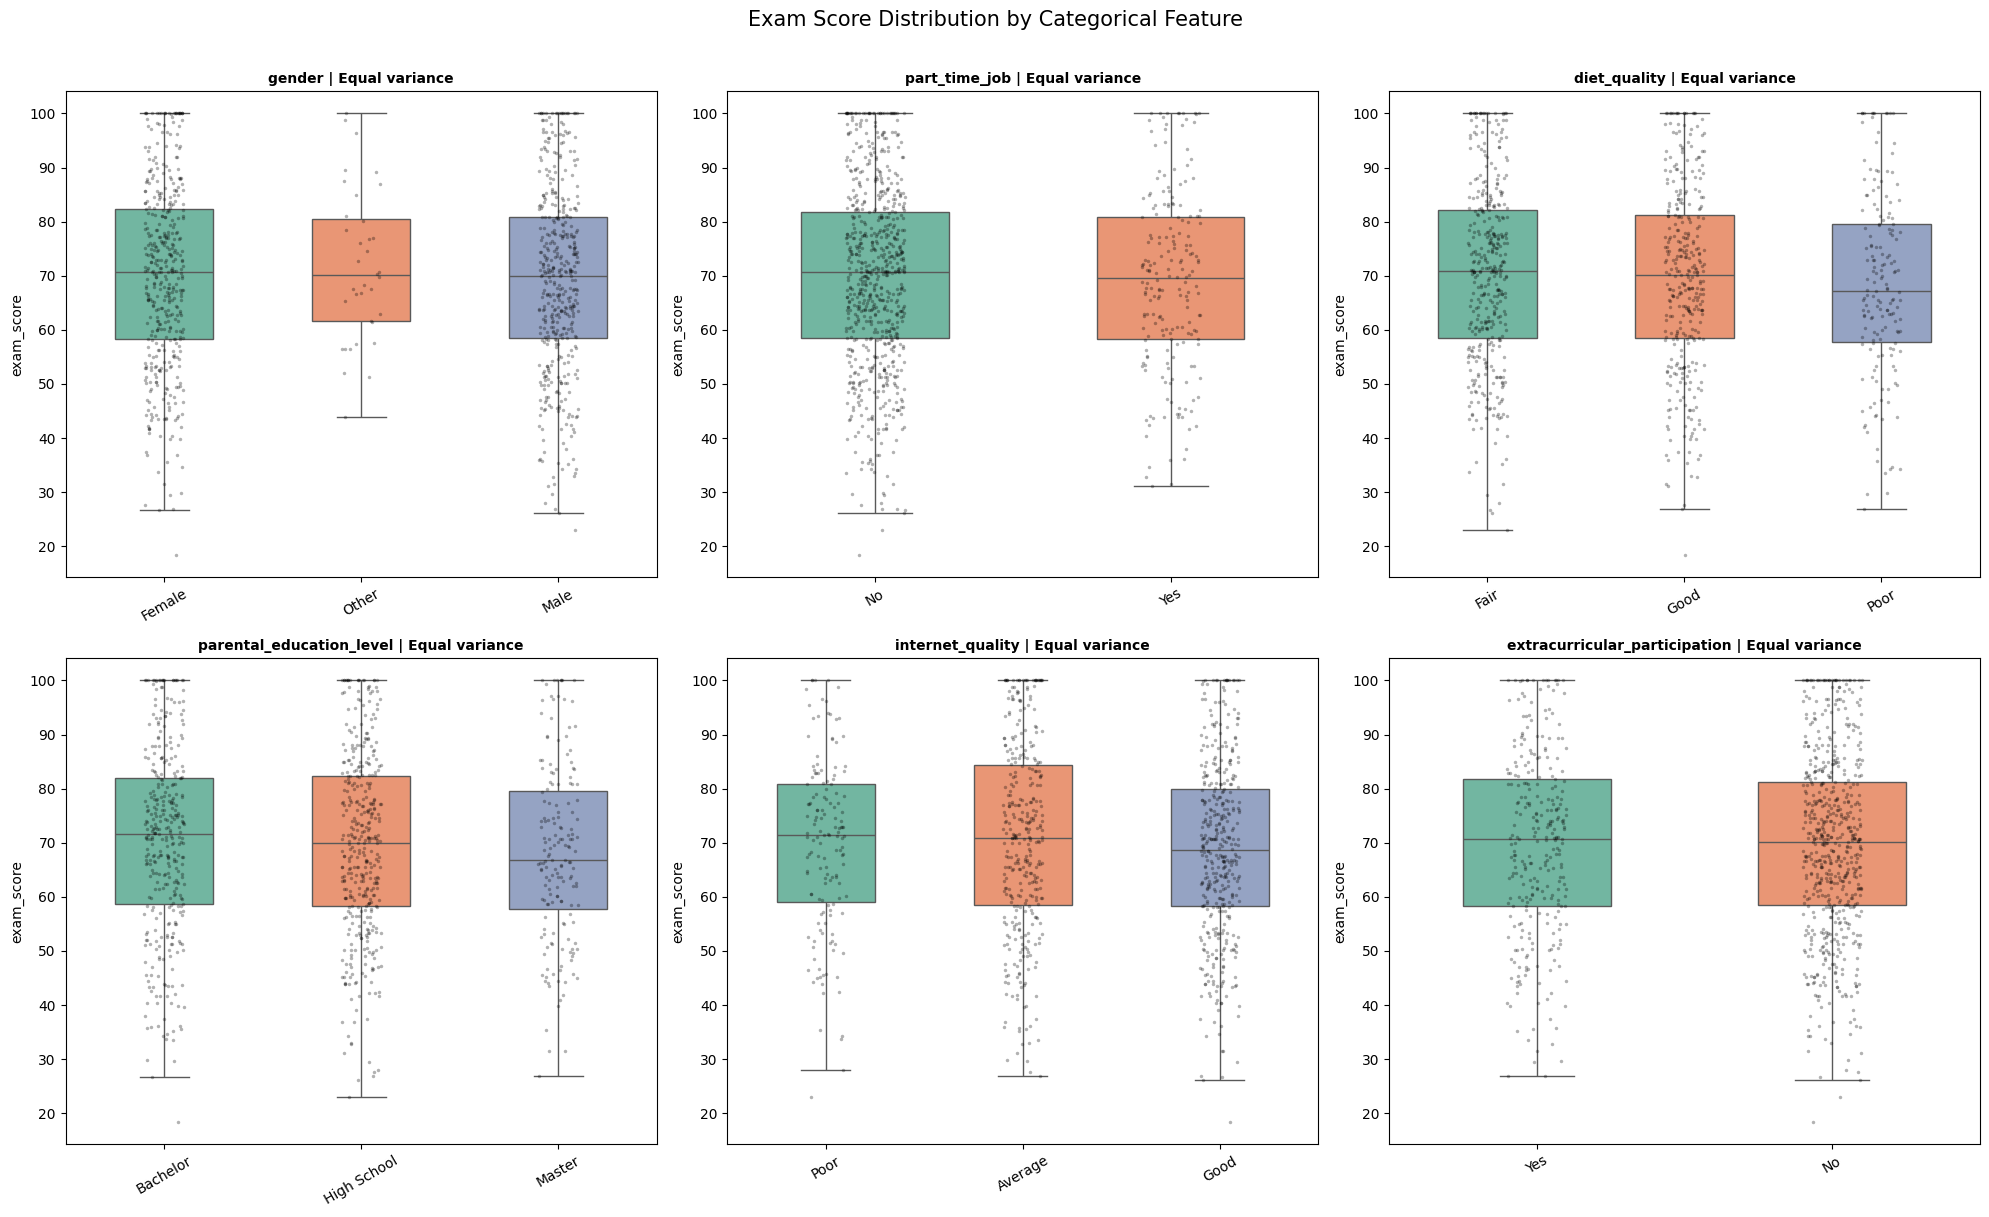

In [9]:
# Phase 2.6 -- Categorical feature box + strip plots vs exam score
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, col in enumerate(CAT_COLS):
    ax = axes[i]
    order = (df.groupby(col)[TARGET].median()
               .sort_values(ascending=False).index.tolist())
    sns.boxplot(data=df, x=col, y=TARGET, order=order,
                palette="Set2", whis=1.5, fliersize=0, ax=ax, width=0.5)
    sns.stripplot(data=df, x=col, y=TARGET, order=order,
                  color="black", size=2.5, alpha=0.3, jitter=True, ax=ax)
    groups = [df[df[col] == g][TARGET].values for g in order]
    try:
        stat, p = levene(*groups)
        sig = "Equal variance" if p > 0.05 else f"Unequal variance (p={p:.3f})"
    except Exception:
        sig = ""
    ax.set_title(f"{col} | {sig}", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Exam Score Distribution by Categorical Feature", fontsize=15, y=1.01)
plt.tight_layout()
savefig("categorical_boxplots", "eda")
plt.show()


  saved -> output_artifacts/eda/mahalanobis_outliers.png


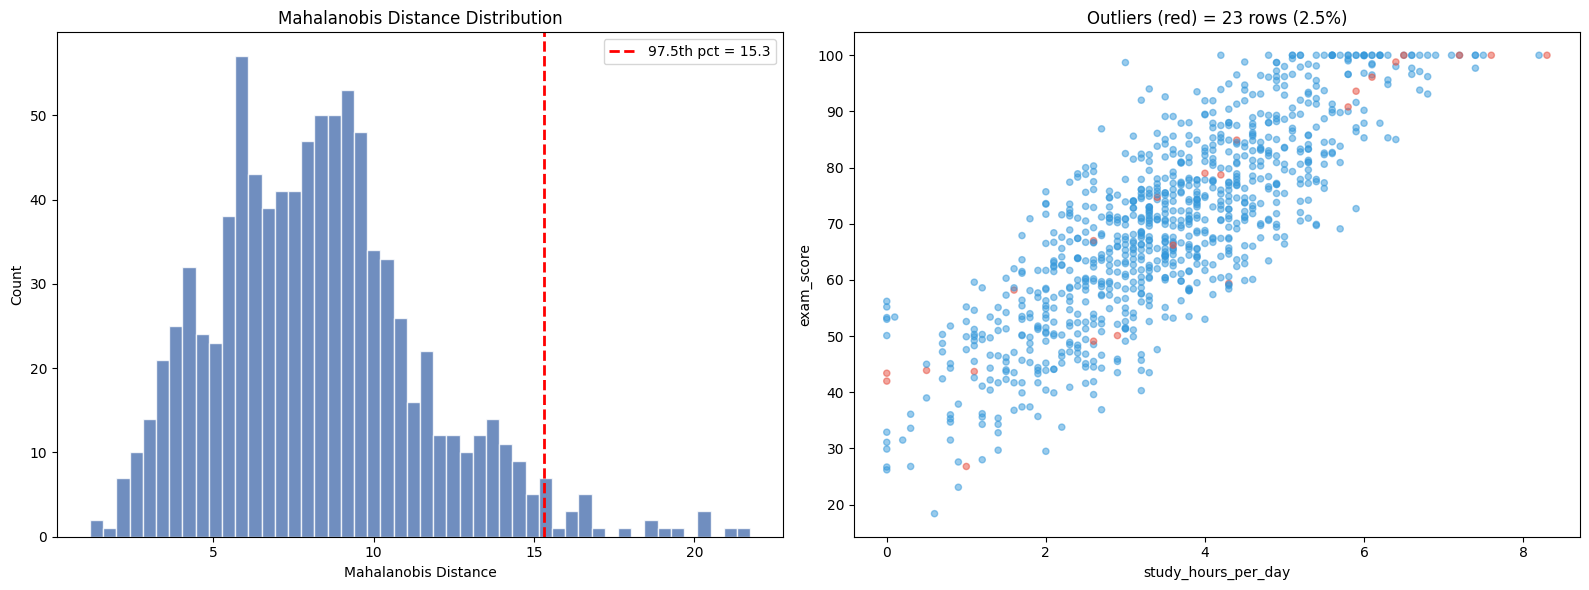

Red dots are multivariate outliers -- extreme in combination, not necessarily individually.


In [10]:
# Phase 2.7 -- Mahalanobis Distance Outlier Detection
md_data = df[NUM_COLS].drop(columns=[TARGET]).values
rmc = MinCovDet(random_state=42).fit(md_data)
md_dist = rmc.mahalanobis(md_data)
df["mahal_dist"]    = md_dist
df["mahal_outlier"] = md_dist > np.percentile(md_dist, 97.5)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].hist(md_dist, bins=50, color="#4C72B0", edgecolor="white", alpha=0.8)
thresh = np.percentile(md_dist, 97.5)
axes[0].axvline(thresh, color="red", lw=2, linestyle="--",
                label=f"97.5th pct = {thresh:.1f}")
axes[0].set_xlabel("Mahalanobis Distance")
axes[0].set_ylabel("Count")
axes[0].set_title("Mahalanobis Distance Distribution")
axes[0].legend()

color_map = df["mahal_outlier"].map({True: "#E74C3C", False: "#3498DB"})
axes[1].scatter(df["study_hours_per_day"], df[TARGET],
                c=color_map, alpha=0.5, s=20)
axes[1].set_xlabel("study_hours_per_day")
axes[1].set_ylabel("exam_score")
outlier_count = df["mahal_outlier"].sum()
outlier_rate  = df["mahal_outlier"].mean()
axes[1].set_title(f"Outliers (red) = {outlier_count} rows ({outlier_rate:.1%})")

plt.tight_layout()
savefig("mahalanobis_outliers", "eda")
plt.show()
print("Red dots are multivariate outliers -- extreme in combination, not necessarily individually.")


  saved -> output_artifacts/eda/facetgrid_diet_internet.png


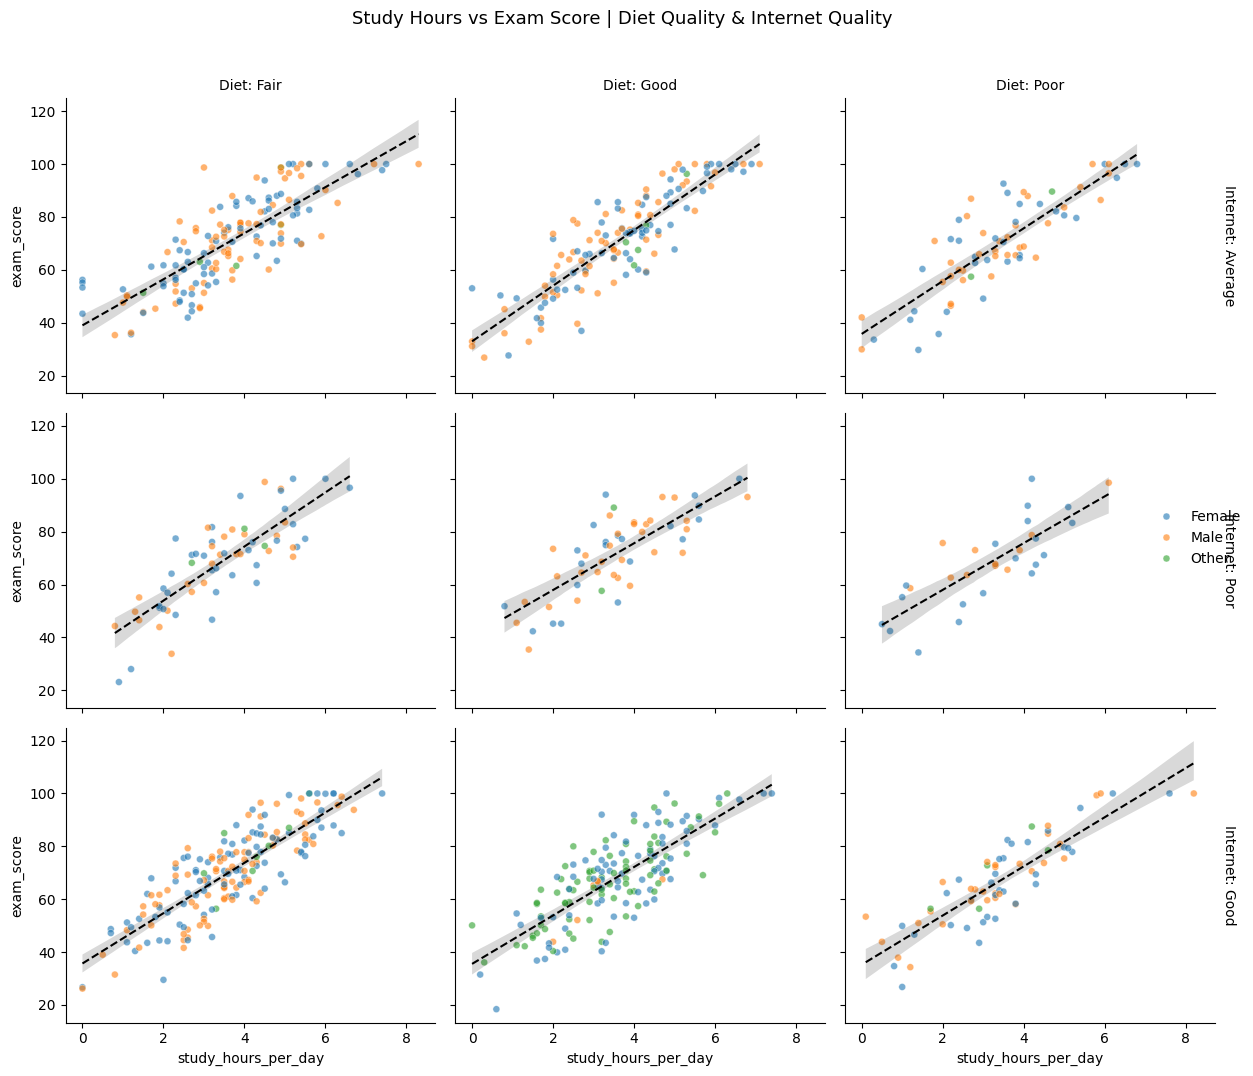

Regression slopes per cell show how study-time ROI varies by lifestyle context.


In [11]:
# Phase 2.8 -- FacetGrid: Study Hours vs Score by Diet & Internet Quality
g = sns.FacetGrid(df, col="diet_quality", row="internet_quality",
                  margin_titles=True, height=3.5, aspect=1.1)
g.map_dataframe(sns.scatterplot, x="study_hours_per_day", y="exam_score",
                hue="gender", alpha=0.6, s=25)
g.map_dataframe(sns.regplot, x="study_hours_per_day", y="exam_score",
                scatter=False, color="black", line_kws={"lw": 1.5, "ls": "--"})
g.add_legend()
g.set_titles(col_template="Diet: {col_name}", row_template="Internet: {row_name}")
g.fig.suptitle("Study Hours vs Exam Score | Diet Quality & Internet Quality",
               y=1.02, fontsize=13)
g.fig.tight_layout()
savefig("facetgrid_diet_internet", "eda")
plt.show()
print("Regression slopes per cell show how study-time ROI varies by lifestyle context.")


  saved -> output_artifacts/eda/mutual_information.png


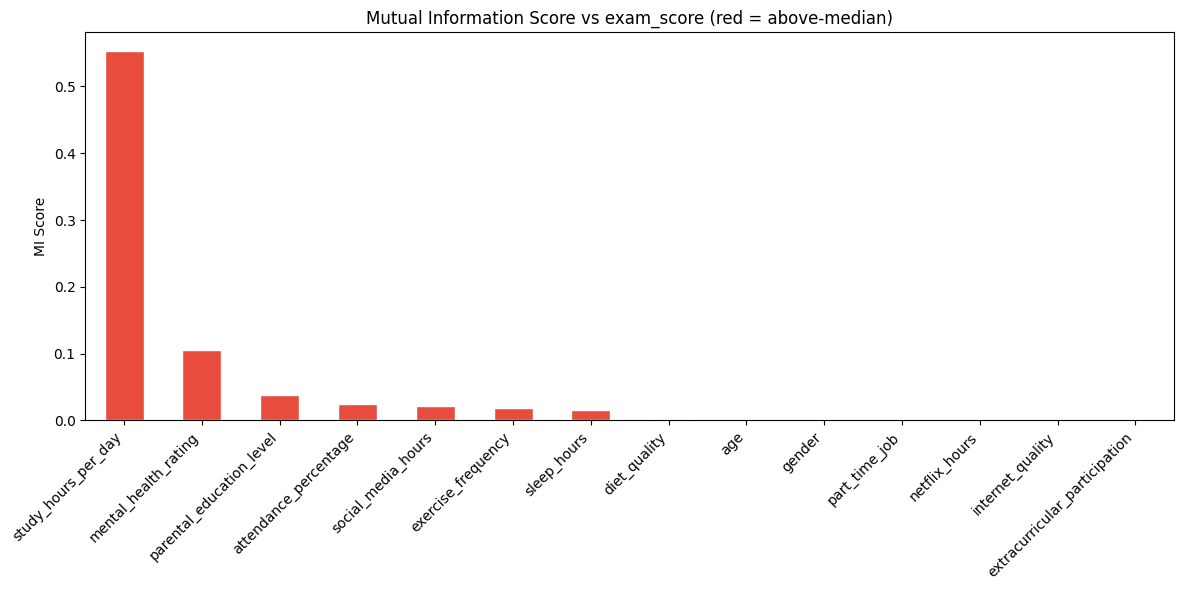

MI measures any (linear or non-linear) dependency with the target.
High MI -> strong predictor regardless of correlation.


In [12]:
# Phase 2.9 -- Mutual Information: non-linear feature relevance
mi_df = df.copy()
for col in CAT_COLS:
    mi_df[col] = LabelEncoder().fit_transform(mi_df[col].astype(str))

mi_feats = [c for c in mi_df.columns
            if c not in [TARGET, "student_id", "mahal_dist", "mahal_outlier"]]
mi_scores = mutual_info_regression(mi_df[mi_feats], mi_df[TARGET], random_state=42)
mi_series  = pd.Series(mi_scores, index=mi_feats).sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ["#E74C3C" if v > mi_series.median() else "#3498DB" for v in mi_series]
mi_series.plot(kind="bar", color=colors, edgecolor="white")
plt.title("Mutual Information Score vs exam_score (red = above-median)", fontsize=12)
plt.ylabel("MI Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
savefig("mutual_information", "eda")
plt.show()
print("MI measures any (linear or non-linear) dependency with the target.")
print("High MI -> strong predictor regardless of correlation.")


---
## Phase 3 -- Advanced Feature Engineering


In [13]:
# Phase 3.1 -- Domain-driven + interaction + polynomial features
fe = df.copy()

# Domain features
fe["total_screen_time"]   = fe["social_media_hours"] + fe["netflix_hours"]
fe["lifestyle_score"]     = (fe["sleep_hours"] + fe["exercise_frequency"] +
                              fe["mental_health_rating"]) / 3
fe["study_effectiveness"] = fe["study_hours_per_day"] * (fe["attendance_percentage"] / 100)
fe["distraction_ratio"]   = fe["total_screen_time"] / (fe["study_hours_per_day"] + 1e-9)
fe["sleep_study_ratio"]   = fe["sleep_hours"] / (fe["study_hours_per_day"] + 1e-9)
fe["wellbeing_index"]     = (fe["mental_health_rating"] * 0.4 +
                              fe["sleep_hours"] * 0.3 +
                              fe["exercise_frequency"] * 0.3)
fe["academic_load"]       = fe["study_hours_per_day"] * fe["attendance_percentage"]
fe["screen_to_sleep"]     = fe["total_screen_time"] / (fe["sleep_hours"] + 1e-9)

# Interaction features
fe["study_x_mental"]      = fe["study_hours_per_day"] * fe["mental_health_rating"]
fe["sleep_x_attendance"]  = fe["sleep_hours"] * fe["attendance_percentage"]

# Polynomial (squared) for key drivers
for col in ["study_hours_per_day", "attendance_percentage", "mental_health_rating"]:
    fe[f"{col}_sq"] = fe[col] ** 2

NEW_FEATURES = [
    "total_screen_time", "lifestyle_score", "study_effectiveness",
    "distraction_ratio", "sleep_study_ratio", "wellbeing_index",
    "academic_load", "screen_to_sleep", "study_x_mental",
    "sleep_x_attendance", "study_hours_per_day_sq",
    "attendance_percentage_sq", "mental_health_rating_sq",
]
print(f"Created {len(NEW_FEATURES)} new features.")


Created 13 new features.


In [14]:
# Phase 3.2 -- Encoding
BINARY_COLS  = ["gender", "part_time_job", "extracurricular_participation"]
ORDINAL_COLS = ["diet_quality", "parental_education_level", "internet_quality"]

le = LabelEncoder()
for col in BINARY_COLS:
    fe[col] = le.fit_transform(fe[col].astype(str))

fe = pd.get_dummies(fe, columns=ORDINAL_COLS, drop_first=True)

# Phase 3.3 -- Define X / y
DROP_COLS = ["student_id", "mahal_dist", "mahal_outlier", TARGET]
X = fe.drop(columns=[c for c in DROP_COLS if c in fe.columns], errors="ignore")
y = fe[TARGET]
print(f"Feature matrix shape: {X.shape}")
print(f"Target shape        : {y.shape}")


Feature matrix shape: (909, 30)
Target shape        : (909,)


  saved -> output_artifacts/features/extratrees_feature_importance.png


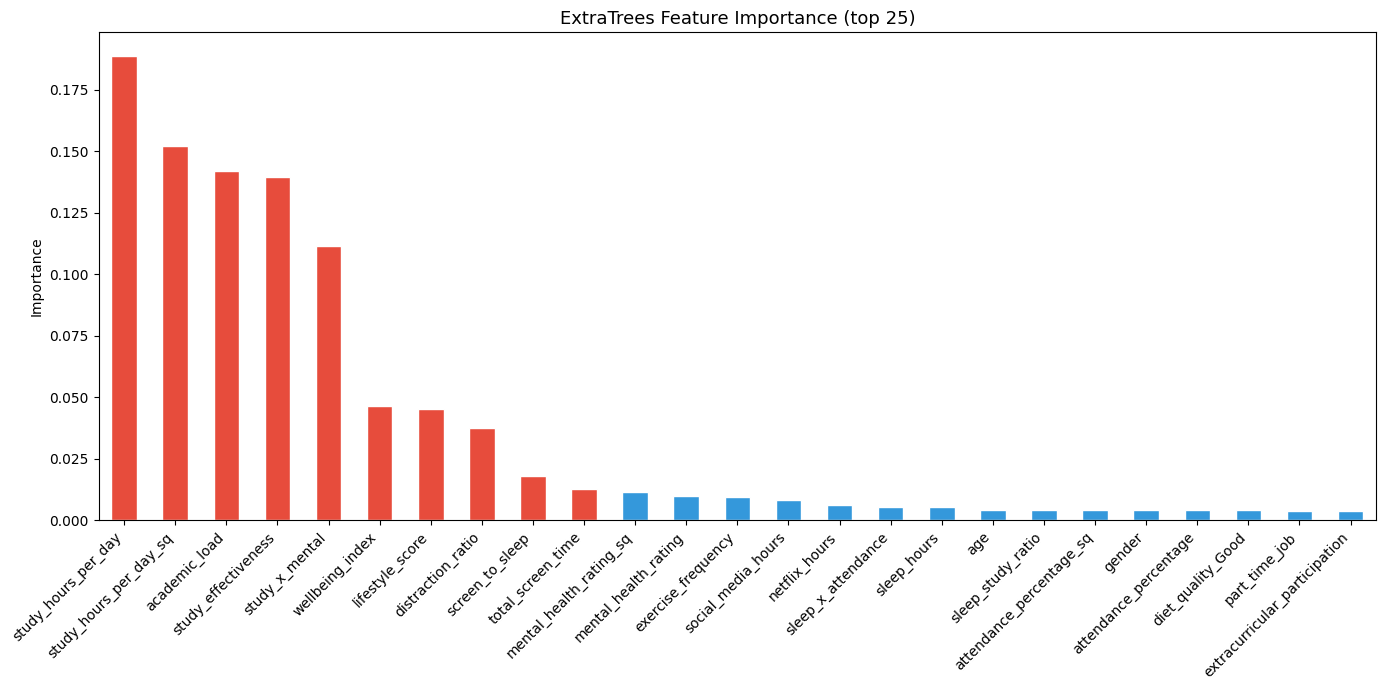

Red bars = top-10 most important features.


In [15]:
# Phase 3.4 -- ExtraTrees quick feature importance
et_quick = ExtraTreesRegressor(n_estimators=200, random_state=42, n_jobs=-1)
et_quick.fit(X, y)

fi = pd.Series(et_quick.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(14, 7))
top_n = 25
colors = ["#E74C3C" if i < 10 else "#3498DB" for i in range(top_n)]
fi.head(top_n).plot(kind="bar", color=colors, edgecolor="white")
plt.title(f"ExtraTrees Feature Importance (top {top_n})", fontsize=13)
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
savefig("extratrees_feature_importance", "features")
plt.show()
print("Red bars = top-10 most important features.")


In [16]:
# Phase 3.5 -- MI-based feature selection + scaling + train/test split
mi_X = mutual_info_regression(X, y, random_state=42)
mi_feats_X = pd.Series(mi_X, index=X.columns).sort_values(ascending=False)

# Keep features above 25th-percentile MI
mi_threshold = np.percentile(mi_X, 25)
SELECTED_FEATURES = mi_feats_X[mi_feats_X >= mi_threshold].index.tolist()
print(f"Features after MI filter: {len(SELECTED_FEATURES)} / {X.shape[1]}")

X_sel = X[SELECTED_FEATURES]

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_sel)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42)

X_train_df = pd.DataFrame(X_train, columns=SELECTED_FEATURES)
X_test_df  = pd.DataFrame(X_test,  columns=SELECTED_FEATURES)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")


Features after MI filter: 22 / 30
Train: (727, 22)  |  Test: (182, 22)


---
## Phase 4 -- Baseline ML Framework
> Replicates the original notebook as the performance benchmark.


In [17]:
# Phase 4.1 -- Baseline model suite (mirrors original notebook)
BASELINE_MODELS = {
    "LinearRegression" : LinearRegression(),
    "Ridge"            : Ridge(alpha=1.0),
    "Lasso"            : Lasso(alpha=0.01),
    "DecisionTree"     : DecisionTreeRegressor(random_state=42),
    "RandomForest"     : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "KNN"              : KNeighborsRegressor(n_neighbors=5),
    "SVR"              : SVR(),
    "XGBoost"          : xgb.XGBRegressor(objective="reg:squarederror", random_state=42, verbosity=0),
    "CatBoost"         : CatBoostRegressor(verbose=0, random_state=42),
}

def evaluate(model, Xtr, ytr, Xte, yte, cv=5):
    """Train model, compute test metrics and cross-val R2."""
    model.fit(Xtr, ytr)
    preds = model.predict(Xte)
    cv_r2 = cross_val_score(model, Xtr, ytr, cv=cv, scoring="r2").mean()
    return {
        "R2"   : r2_score(yte, preds),
        "RMSE" : np.sqrt(mean_squared_error(yte, preds)),
        "MAE"  : mean_absolute_error(yte, preds),
        "MAPE" : mean_absolute_percentage_error(yte, preds) * 100,
        "CV_R2": cv_r2,
    }

baseline_results = {}
for name, model in BASELINE_MODELS.items():
    metrics = evaluate(model, X_train, y_train, X_test, y_test)
    baseline_results[name] = metrics
    print(f"  {name:<22} R2={metrics["R2"]:.4f}  RMSE={metrics["RMSE"]:.3f}  CV_R2={metrics["CV_R2"]:.4f}")

baseline_df = pd.DataFrame(baseline_results).T.sort_values("R2", ascending=False)


  LinearRegression       R2=0.8954  RMSE=5.327  CV_R2=0.9005
  Ridge                  R2=0.8932  RMSE=5.383  CV_R2=0.8998
  Lasso                  R2=0.8948  RMSE=5.343  CV_R2=0.9010
  DecisionTree           R2=0.7761  RMSE=7.795  CV_R2=0.7590
  RandomForest           R2=0.8956  RMSE=5.324  CV_R2=0.8822
  KNN                    R2=0.8225  RMSE=6.941  CV_R2=0.8456
  SVR                    R2=-0.0028  RMSE=16.498  CV_R2=0.0132
  XGBoost                R2=0.8623  RMSE=6.113  CV_R2=0.8679
  CatBoost               R2=0.8960  RMSE=5.314  CV_R2=0.8851


  saved -> output_artifacts/models/baseline_model_comparison.png


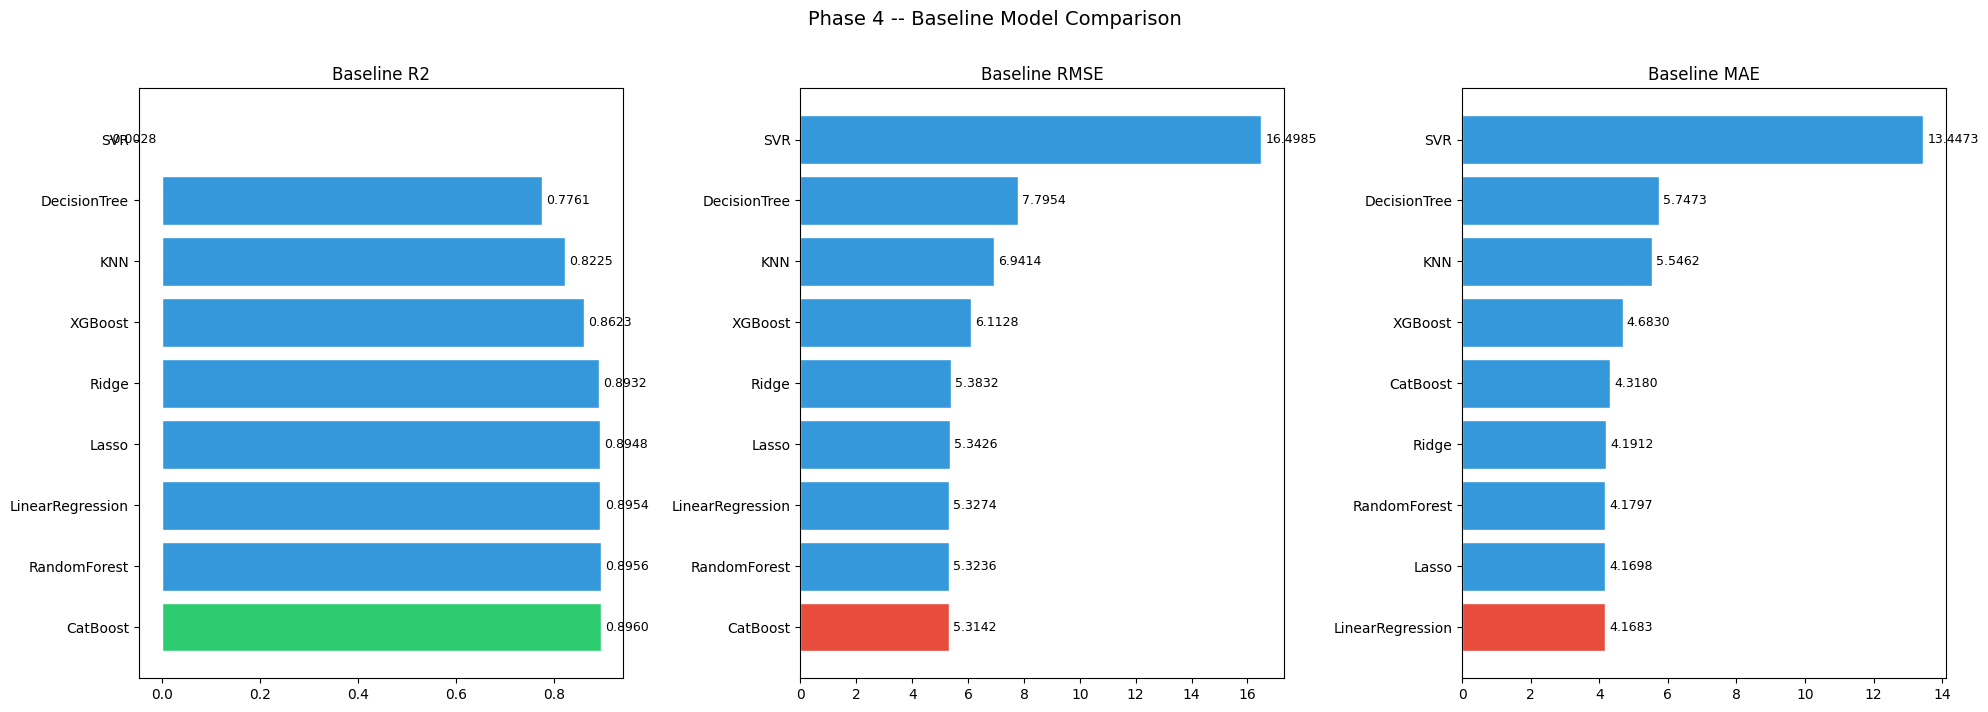

Baseline Summary Table:
                      R2    RMSE     MAE    MAPE  CV_R2
CatBoost          0.8960  5.3142  4.3180  6.5463 0.8851
RandomForest      0.8956  5.3236  4.1797  6.2898 0.8822
LinearRegression  0.8954  5.3274  4.1683  6.2607 0.9005
Lasso             0.8948  5.3426  4.1698  6.2177 0.9010
Ridge             0.8932  5.3832  4.1912  6.2332 0.8998
XGBoost           0.8623  6.1128  4.6830  7.0214 0.8679
KNN               0.8225  6.9414  5.5462  8.4849 0.8456
DecisionTree      0.7761  7.7954  5.7473  8.6346 0.7590
SVR              -0.0028 16.4985 13.4473 21.2170 0.0132


In [18]:
# Phase 4.2 -- Baseline comparison visual
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, metric in zip(axes, ["R2", "RMSE", "MAE"]):
    data = baseline_df[metric].sort_values(ascending=(metric != "R2"))
    if metric == "R2":
        colors = ["#2ECC71" if v == data.max() else "#3498DB" for v in data]
    else:
        colors = ["#E74C3C" if v == data.min() else "#3498DB" for v in data]
    bars = ax.barh(data.index, data.values, color=colors, edgecolor="white")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_title(f"Baseline {metric}", fontsize=12)

plt.suptitle("Phase 4 -- Baseline Model Comparison", fontsize=14, y=1.01)
plt.tight_layout()
savefig("baseline_model_comparison", "models")
plt.show()

print("Baseline Summary Table:")
print(baseline_df.to_string(float_format="{:.4f}".format))


---
## Phase 5 -- Advanced ML Framework
### Optuna Tuning, Regularisation, Stacking & Voting Ensembles


In [19]:
# Phase 5.1 -- Optuna hyperparameter tuning: XGBoost
def xgb_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 300, 1200, step=100),
        "max_depth"        : trial.suggest_int("max_depth", 3, 10),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight" : trial.suggest_int("min_child_weight", 1, 10),
        "gamma"            : trial.suggest_float("gamma", 0, 5),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
        "objective"        : "reg:squarederror",
        "random_state"     : 42,
        "verbosity"        : 0,
        "n_jobs"           : -1,
    }
    model  = xgb.XGBRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
    return scores.mean()

study_xgb = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=60, show_progress_bar=True)

best_xgb_params = dict(study_xgb.best_params)
best_xgb_params.update({"objective": "reg:squarederror", "random_state": 42,
                          "verbosity": 0, "n_jobs": -1})
xgb_tuned = xgb.XGBRegressor(**best_xgb_params)
xgb_tuned.fit(X_train, y_train)
print(f"XGBoost best CV R2 = {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")


  0%|          | 0/60 [00:00<?, ?it/s]

XGBoost best CV R2 = 0.8928
Best params: {'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.016753861443025236, 'subsample': 0.6931136793757502, 'colsample_bytree': 0.5634817864345281, 'min_child_weight': 9, 'gamma': 3.3410796137134415, 'reg_alpha': 0.07252474700219409, 'reg_lambda': 4.246135459170971e-08}


In [20]:
# Phase 5.2 -- Optuna tuning: LightGBM
def lgb_objective(trial):
    params = {
        "n_estimators"     : trial.suggest_int("n_estimators", 300, 1500, step=100),
        "max_depth"        : trial.suggest_int("max_depth", 3, 12),
        "learning_rate"    : trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        "num_leaves"       : trial.suggest_int("num_leaves", 20, 300),
        "subsample"        : trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree" : trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha"        : trial.suggest_float("reg_alpha", 1e-8, 10, log=True),
        "reg_lambda"       : trial.suggest_float("reg_lambda", 1e-8, 10, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "random_state"     : 42,
        "verbose"          : -1,
        "n_jobs"           : -1,
    }
    model  = lgb.LGBMRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
    return scores.mean()

study_lgb = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(lgb_objective, n_trials=60, show_progress_bar=True)

best_lgb_params = dict(study_lgb.best_params)
best_lgb_params.update({"random_state": 42, "verbose": -1, "n_jobs": -1})
lgb_tuned = lgb.LGBMRegressor(**best_lgb_params)
lgb_tuned.fit(X_train, y_train)
print(f"LightGBM best CV R2 = {study_lgb.best_value:.4f}")


  0%|          | 0/60 [00:00<?, ?it/s]

LightGBM best CV R2 = 0.8914


In [21]:
# Phase 5.3 -- Optuna tuning: CatBoost
def cat_objective(trial):
    params = {
        "iterations"        : trial.suggest_int("iterations", 300, 1500, step=100),
        "depth"             : trial.suggest_int("depth", 4, 10),
        "learning_rate"     : trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg"       : trial.suggest_float("l2_leaf_reg", 1e-3, 10, log=True),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "random_strength"   : trial.suggest_float("random_strength", 0, 10),
        "random_seed"       : 42,
        "verbose"           : 0,
    }
    model  = CatBoostRegressor(**params)
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
    return scores.mean()

study_cat = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=42))
study_cat.optimize(cat_objective, n_trials=40, show_progress_bar=True)

best_cat_params = dict(study_cat.best_params)
best_cat_params.update({"random_seed": 42, "verbose": 0})
cat_tuned = CatBoostRegressor(**best_cat_params)
cat_tuned.fit(X_train, y_train)
print(f"CatBoost best CV R2 = {study_cat.best_value:.4f}")


  0%|          | 0/40 [00:00<?, ?it/s]

CatBoost best CV R2 = 0.8969


In [22]:
# Phase 5.4 -- Regularised linear baselines
alphas    = np.logspace(-3, 3, 30)
ridge_cv  = RidgeCV(alphas=alphas, cv=5).fit(X_train, y_train)
lasso_cv  = LassoCV(alphas=alphas, cv=5, max_iter=5000, random_state=42).fit(X_train, y_train)
elastic   = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000, random_state=42).fit(X_train, y_train)
huber     = HuberRegressor(max_iter=500).fit(X_train, y_train)
bayesian  = BayesianRidge().fit(X_train, y_train)

print(f"Ridge best alpha={ridge_cv.alpha_:.4f}  |  Lasso best alpha={lasso_cv.alpha_:.4f}")


Ridge best alpha=0.1887  |  Lasso best alpha=0.0174


In [23]:
# Phase 5.5 -- Stacking Ensemble (XGB + LGB + CAT + RF + ET -> Ridge meta)
estimators_stack = [
    ("xgb", xgb_tuned),
    ("lgb", lgb_tuned),
    ("cat", cat_tuned),
    ("rf",  RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    ("et",  ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
]

stacking = StackingRegressor(
    estimators=estimators_stack,
    final_estimator=Ridge(alpha=1.0),
    cv=5, n_jobs=-1, passthrough=False,
)
stacking.fit(X_train, y_train)
print("Stacking ensemble trained.")

# Phase 5.6 -- Voting Ensemble
voting = VotingRegressor(
    estimators=[("xgb", xgb_tuned), ("lgb", lgb_tuned), ("cat", cat_tuned)],
    n_jobs=-1,
)
voting.fit(X_train, y_train)
print("Voting ensemble trained.")


Stacking ensemble trained.
Voting ensemble trained.


In [24]:
# Phase 5.7 -- Evaluate all advanced models
ADVANCED_MODELS = {
    "XGB_Tuned"    : xgb_tuned,
    "LGB_Tuned"    : lgb_tuned,
    "CAT_Tuned"    : cat_tuned,
    "Ridge_CV"     : ridge_cv,
    "Lasso_CV"     : lasso_cv,
    "ElasticNet"   : elastic,
    "HuberReg"     : huber,
    "BayesianRidge": bayesian,
    "Stacking"     : stacking,
    "Voting"       : voting,
}

adv_results = {}
for name, model in ADVANCED_MODELS.items():
    preds = model.predict(X_test)
    adv_results[name] = {
        "R2"  : r2_score(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE" : mean_absolute_error(y_test, preds),
        "MAPE": mean_absolute_percentage_error(y_test, preds) * 100,
    }
    print(f"  {name:<18} R2={adv_results[name]["R2"]:.4f}  RMSE={adv_results[name]["RMSE"]:.3f}")

adv_df = pd.DataFrame(adv_results).T.sort_values("R2", ascending=False)


  XGB_Tuned          R2=0.8997  RMSE=5.218
  LGB_Tuned          R2=0.8914  RMSE=5.429
  CAT_Tuned          R2=0.9027  RMSE=5.140
  Ridge_CV           R2=0.8952  RMSE=5.335
  Lasso_CV           R2=0.8942  RMSE=5.358
  ElasticNet         R2=0.8883  RMSE=5.506
  HuberReg           R2=-18.5592  RMSE=72.863
  BayesianRidge      R2=0.8944  RMSE=5.355
  Stacking           R2=0.9017  RMSE=5.165
  Voting             R2=0.9010  RMSE=5.183


  saved -> output_artifacts/models/advanced_ml_comparison.png


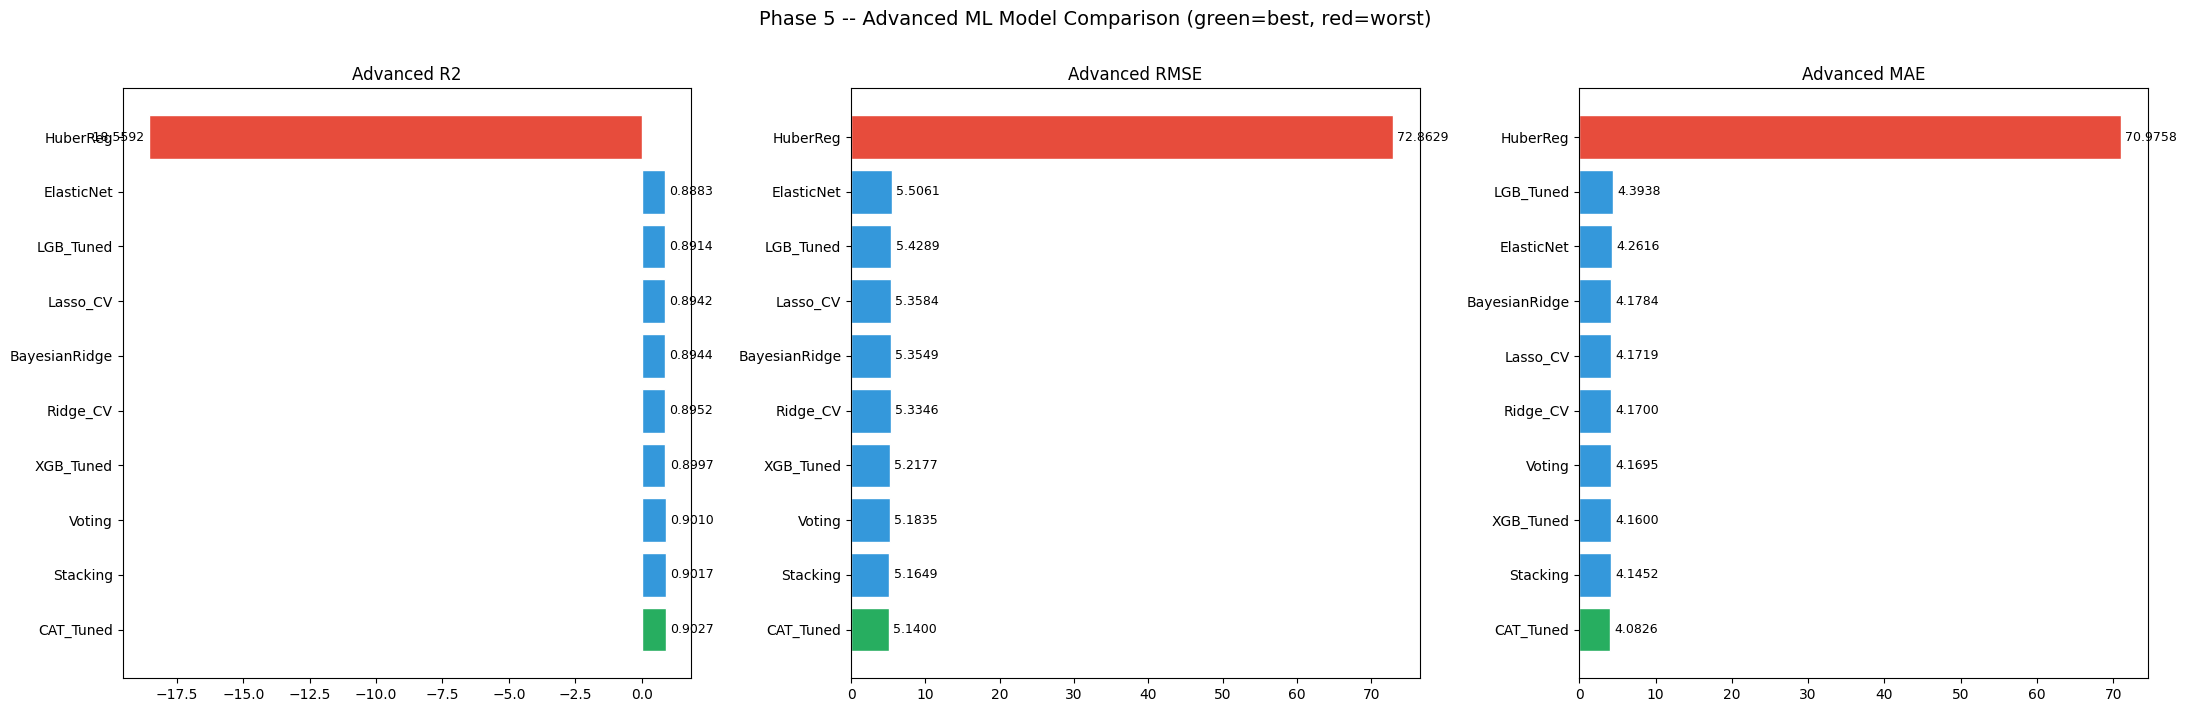

In [25]:
# Phase 5.8 -- Advanced ML visual comparison
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for ax, metric in zip(axes, ["R2", "RMSE", "MAE"]):
    data = adv_df[metric].sort_values(ascending=(metric != "R2"))
    if metric == "R2":
        palette = ["#27AE60" if v == data.max() else "#E74C3C"
                   if v == data.min() else "#3498DB" for v in data]
    else:
        palette = ["#27AE60" if v == data.min() else "#E74C3C"
                   if v == data.max() else "#3498DB" for v in data]
    bars = ax.barh(data.index, data.values, color=palette, edgecolor="white")
    ax.bar_label(bars, fmt="%.4f", padding=3, fontsize=9)
    ax.set_title(f"Advanced {metric}", fontsize=12)

plt.suptitle("Phase 5 -- Advanced ML Model Comparison (green=best, red=worst)",
             fontsize=14, y=1.01)
plt.tight_layout()
savefig("advanced_ml_comparison", "models")
plt.show()


---
## Phase 6 -- Ultra-Advanced Deep Learning Framework
### ANN Baseline | Deep ANN | ResNet-style | Wide & Deep


In [26]:
# Phase 6.1 -- Define all DL architectures
n_feat = X_train.shape[1]

def build_ann_baseline():
    """Original-notebook-style ANN: 3x64 Dense + Dropout."""
    m = Sequential([
        KInput(shape=(n_feat,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(1),
    ], name="ANN_Baseline")
    m.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return m

def build_ann_deep():
    """Deeper ANN: 256->128->64->32 with BatchNorm + L2 regularisation."""
    m = Sequential([
        KInput(shape=(n_feat,)),
        layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.3),
        layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.25),
        layers.Dense(64, activation="relu"),
        layers.BatchNormalization(), layers.Dropout(0.2),
        layers.Dense(32, activation="relu"),
        layers.Dense(1),
    ], name="ANN_Deep")
    m.compile(optimizer=optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return m

def build_residual():
    """ResNet-style with skip connections."""
    inputs = KInput(shape=(n_feat,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    res = x
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Add()([x, res])
    res2 = x
    x = layers.Dense(128, activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Add()([x, res2])
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1)(x)
    m = Model(inputs, out, name="ResNet_Style")
    m.compile(optimizer=optimizers.Adam(5e-4), loss="mse", metrics=["mae"])
    return m

def build_wide_deep():
    """Wide & Deep: raw features (wide path) + deep path concatenated."""
    inputs = KInput(shape=(n_feat,))
    deep   = layers.Dense(128, activation="relu")(inputs)
    deep   = layers.BatchNormalization()(deep)
    deep   = layers.Dropout(0.3)(deep)
    deep   = layers.Dense(64, activation="relu")(deep)
    deep   = layers.BatchNormalization()(deep)
    deep   = layers.Dropout(0.2)(deep)
    deep   = layers.Dense(32, activation="relu")(deep)
    wide   = layers.Dense(32, activation="relu")(inputs)
    concat = layers.Concatenate()([wide, deep])
    out    = layers.Dense(1)(concat)
    m = Model(inputs, out, name="Wide_Deep")
    m.compile(optimizer=optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
    return m

dl_factories = {
    "ANN_Baseline": build_ann_baseline,
    "ANN_Deep"    : build_ann_deep,
    "ResNet_Style": build_residual,
    "Wide_Deep"   : build_wide_deep,
}

print("DL architectures defined:")
for name, fn in dl_factories.items():
    m = fn()
    print(f"  {name:<18} params={m.count_params():,}")


DL architectures defined:
  ANN_Baseline       params=9,857
  ANN_Deep           params=50,945
  ResNet_Style       params=74,689
  Wide_Deep          params=14,849


In [27]:
# Phase 6.2 -- Train all DL models with EarlyStopping + ReduceLROnPlateau
cb_common = [
    callbacks.EarlyStopping(monitor="val_loss", patience=15,
                            restore_best_weights=True, verbose=0),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=7, verbose=0),
]

dl_results   = {}
dl_histories = {}
dl_trained   = {}

for name, factory in dl_factories.items():
    print(f"Training {name} ...")
    model = factory()
    hist  = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=150,
        batch_size=32,
        callbacks=cb_common,
        verbose=0,
    )
    preds = model.predict(X_test, verbose=0).flatten()
    dl_results[name] = {
        "R2"  : r2_score(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE" : mean_absolute_error(y_test, preds),
        "MAPE": mean_absolute_percentage_error(y_test, preds) * 100,
    }
    dl_histories[name] = hist.history
    dl_trained[name]   = model
    print(f"  R2={dl_results[name]["R2"]:.4f}  RMSE={dl_results[name]["RMSE"]:.3f}"          f"  stopped at epoch {len(hist.history["loss"])}")

dl_df = pd.DataFrame(dl_results).T.sort_values("R2", ascending=False)
print("All DL models trained.")


Training ANN_Baseline ...
  R2=-0.4925  RMSE=20.128  stopped at epoch 75
Training ANN_Deep ...
  R2=0.5142  RMSE=11.483  stopped at epoch 39
Training ResNet_Style ...


  R2=-18.2351  RMSE=72.257  stopped at epoch 15
Training Wide_Deep ...


  R2=-18.5249  RMSE=72.799  stopped at epoch 15
All DL models trained.


  saved -> output_artifacts/models/dl_training_curves.png


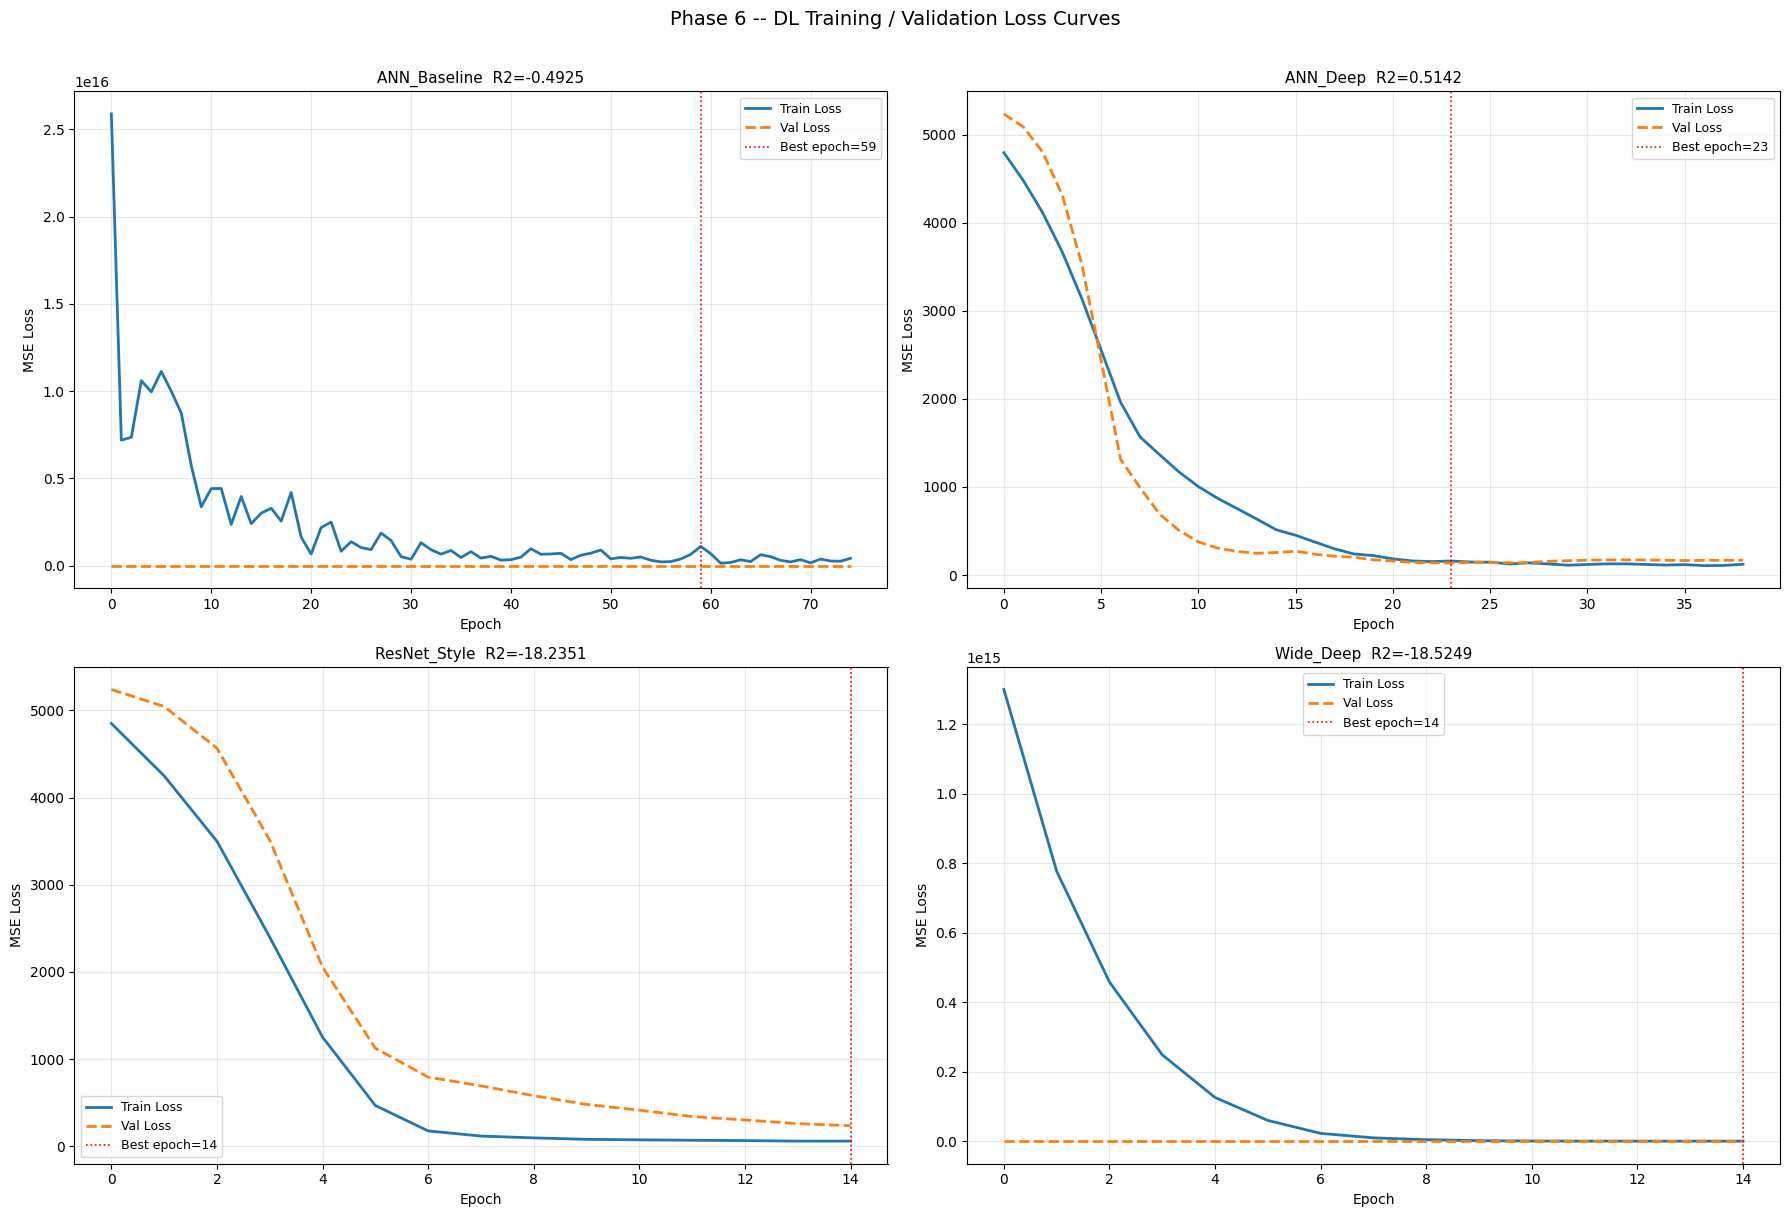

In [28]:
# Phase 6.3 -- Training curves for all DL models
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for i, (name, hist) in enumerate(dl_histories.items()):
    ax = axes[i]
    ax.plot(hist["loss"],     label="Train Loss", lw=2)
    ax.plot(hist["val_loss"], label="Val Loss",   lw=2, linestyle="--")
    best_ep = int(np.argmin(hist["val_loss"]))
    ax.axvline(best_ep, color="red", lw=1.2, linestyle=":", label=f"Best epoch={best_ep}")
    ax.set_title(f"{name}  R2={dl_results[name]["R2"]:.4f}", fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle("Phase 6 -- DL Training / Validation Loss Curves", fontsize=14, y=1.01)
plt.tight_layout()
savefig("dl_training_curves", "models")
plt.show()


---
## Phase 7 -- Full Model Orchestration & Final Comparison


In [29]:
# Phase 7.1 -- Consolidate ALL model results
all_results = {}
all_results.update({f"BL_{k}": v for k, v in baseline_results.items()})
all_results.update({f"ADV_{k}": v for k, v in adv_results.items()})
all_results.update({f"DL_{k}": v for k, v in dl_results.items()})

all_df = pd.DataFrame(all_results).T[["R2", "RMSE", "MAE", "MAPE"]].copy()
all_df = all_df.sort_values("R2", ascending=False)
all_df["Tier"] = all_df.index.map(lambda x:
    "Deep Learning" if x.startswith("DL_") else
    "Advanced ML"   if x.startswith("ADV_") else
    "Baseline ML")

print(f"Total models compared: {len(all_df)}")
print(all_df.to_string(float_format="{:.4f}".format))


Total models compared: 23
                          R2    RMSE     MAE     MAPE           Tier
ADV_CAT_Tuned         0.9027  5.1400  4.0826   6.1583    Advanced ML
ADV_Stacking          0.9017  5.1649  4.1452   6.2625    Advanced ML
ADV_Voting            0.9010  5.1835  4.1695   6.3150    Advanced ML
ADV_XGB_Tuned         0.8997  5.2177  4.1600   6.3059    Advanced ML
BL_CatBoost           0.8960  5.3142  4.3180   6.5463    Baseline ML
BL_RandomForest       0.8956  5.3236  4.1797   6.2898    Baseline ML
BL_LinearRegression   0.8954  5.3274  4.1683   6.2607    Baseline ML
ADV_Ridge_CV          0.8952  5.3346  4.1700   6.2455    Advanced ML
BL_Lasso              0.8948  5.3426  4.1698   6.2177    Baseline ML
ADV_BayesianRidge     0.8944  5.3549  4.1784   6.2342    Advanced ML
ADV_Lasso_CV          0.8942  5.3584  4.1719   6.2001    Advanced ML
BL_Ridge              0.8932  5.3832  4.1912   6.2332    Baseline ML
ADV_LGB_Tuned         0.8914  5.4289  4.3938   6.6790    Advanced ML
ADV_Elas

  saved -> output_artifacts/models/master_model_comparison.png


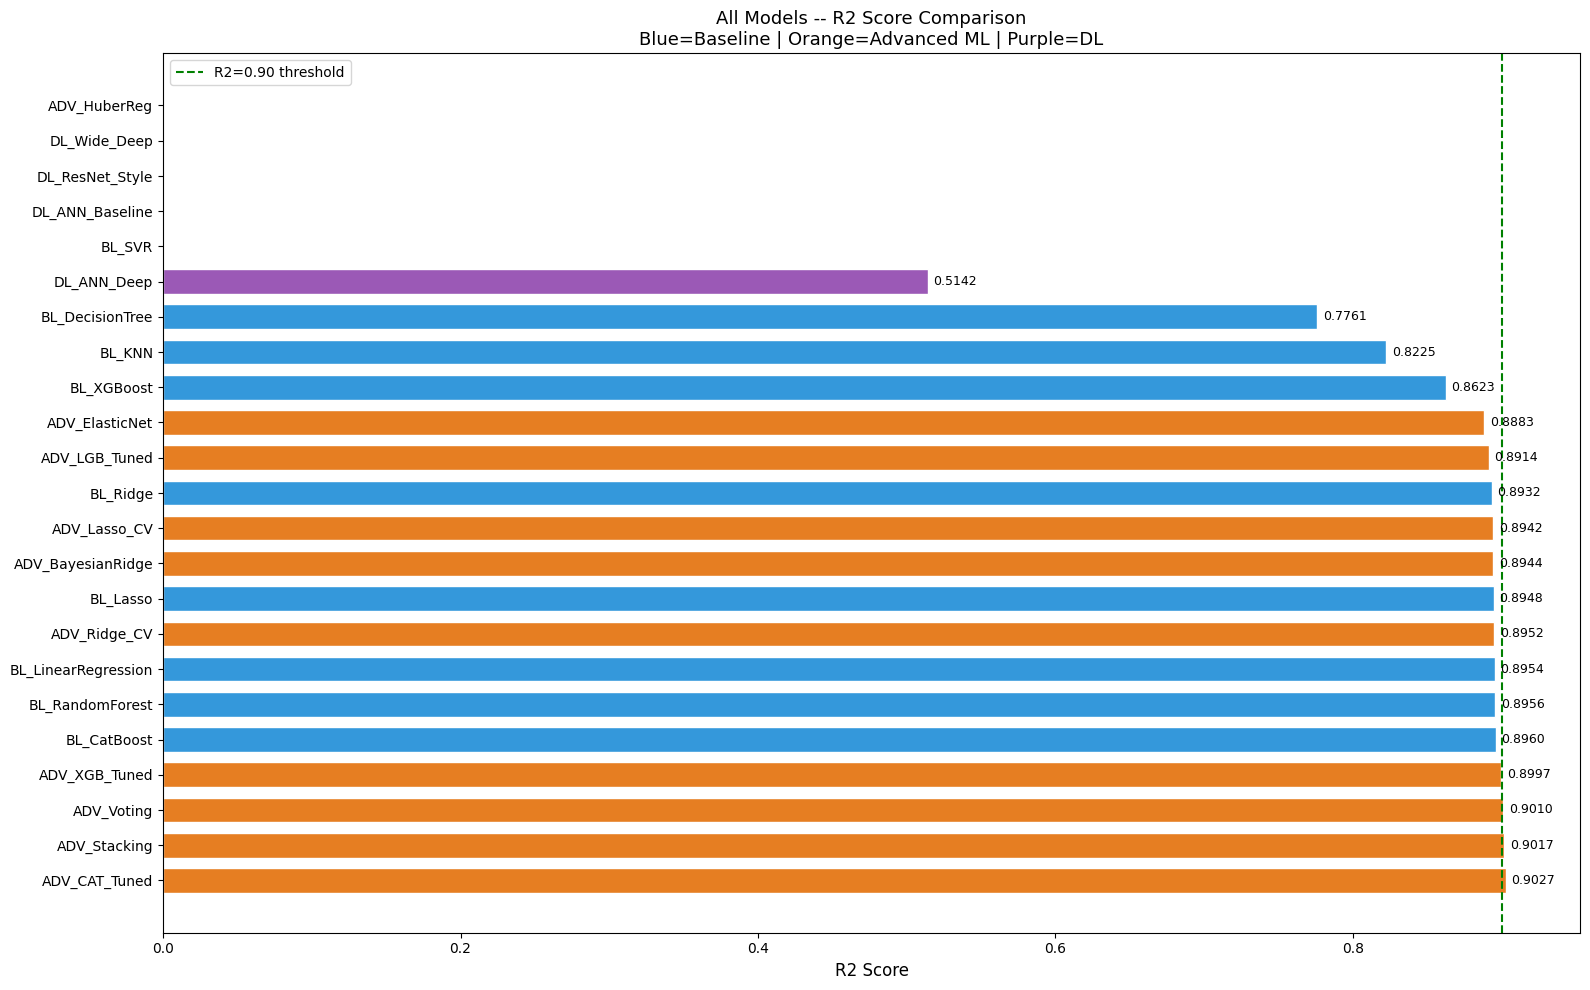

In [30]:
# Phase 7.2 -- Master comparison chart (all models ranked by R2)
tier_colors = {"Baseline ML": "#3498DB", "Advanced ML": "#E67E22",
               "Deep Learning": "#9B59B6"}

fig, ax = plt.subplots(figsize=(16, 10))
colors  = [tier_colors[t] for t in all_df["Tier"]]
bars    = ax.barh(all_df.index, all_df["R2"], color=colors, edgecolor="white", height=0.7)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
ax.set_xlabel("R2 Score", fontsize=12)
ax.set_title("All Models -- R2 Score Comparison\nBlue=Baseline | Orange=Advanced ML | Purple=DL",
             fontsize=13)
ax.axvline(0.9, color="green", lw=1.5, linestyle="--", label="R2=0.90 threshold")
ax.legend()
ax.set_xlim(0, all_df["R2"].max() + 0.05)
plt.tight_layout()
savefig("master_model_comparison", "models")
plt.show()


  saved -> output_artifacts/models/predicted_vs_actual_top3.png


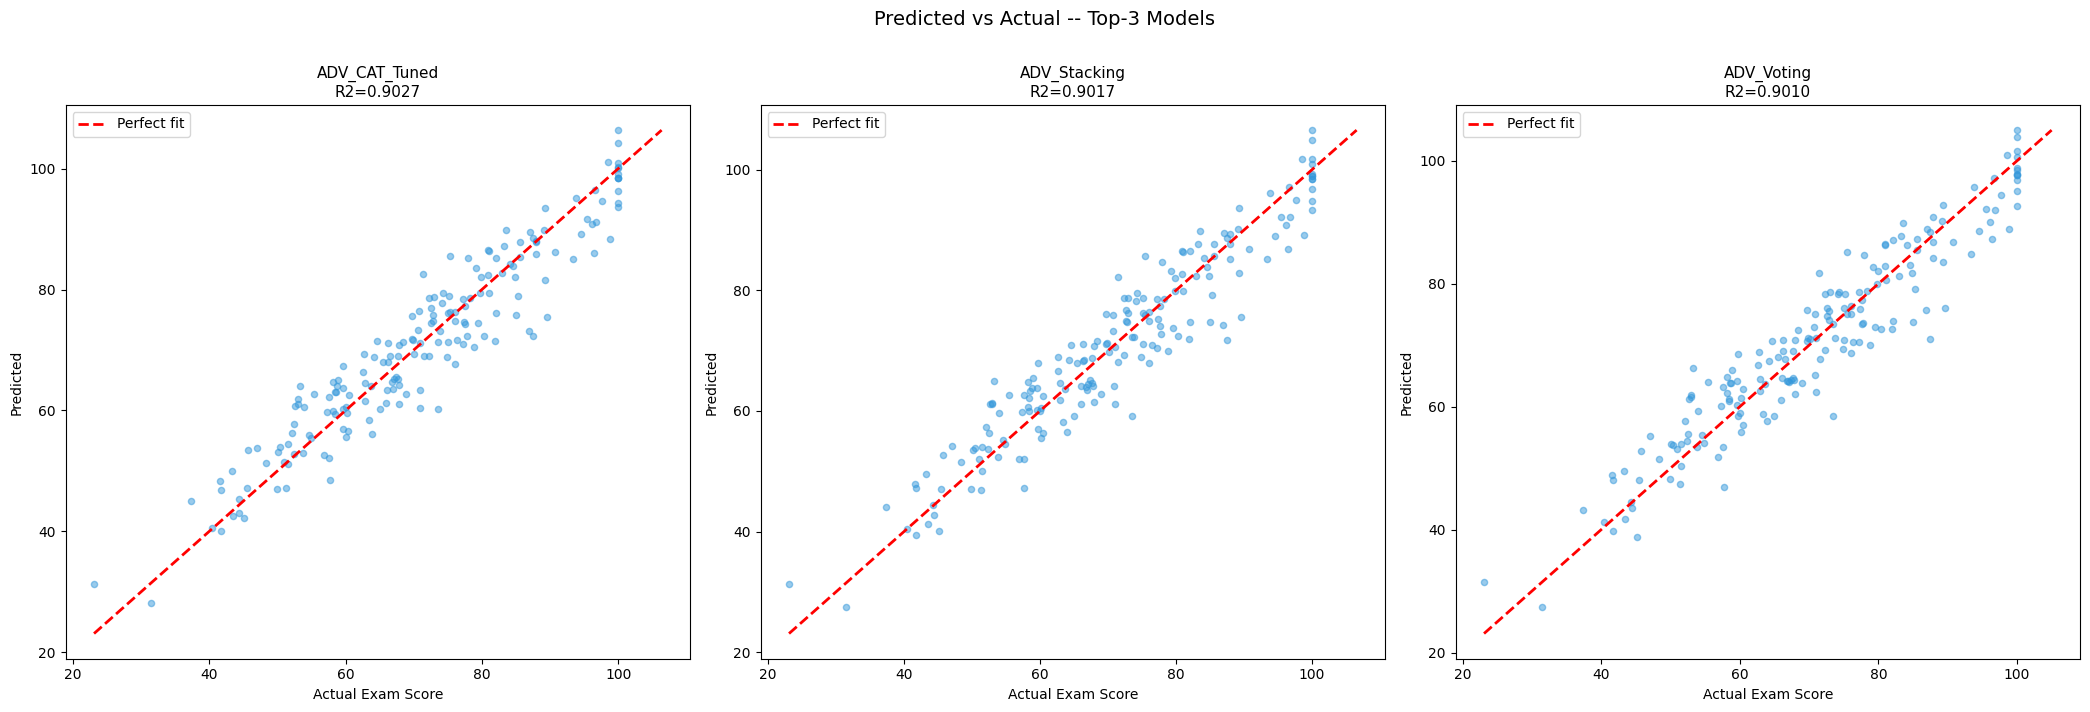

In [31]:
# Phase 7.3 -- Helper: get predictions for any labelled model
def get_preds(label):
    if label.startswith("DL_"):
        return dl_trained[label[3:]].predict(X_test, verbose=0).flatten()
    elif label.startswith("ADV_"):
        return ADVANCED_MODELS[label[4:]].predict(X_test)
    else:
        return BASELINE_MODELS[label[3:]].predict(X_test)

# Predicted vs Actual for top-3 models
top3_names = all_df.index[:3].tolist()

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
for ax, name in zip(axes, top3_names):
    preds = get_preds(name)
    r2    = r2_score(y_test, preds)
    ax.scatter(y_test, preds, alpha=0.5, s=20, c="#3498DB")
    lo, hi = min(float(y_test.min()), float(preds.min())), max(float(y_test.max()), float(preds.max()))
    ax.plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect fit")
    ax.set_xlabel("Actual Exam Score")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name}\nR2={r2:.4f}", fontsize=11)
    ax.legend()

plt.suptitle("Predicted vs Actual -- Top-3 Models", fontsize=14, y=1.01)
plt.tight_layout()
savefig("predicted_vs_actual_top3", "models")
plt.show()


  saved -> output_artifacts/models/residual_analysis.png


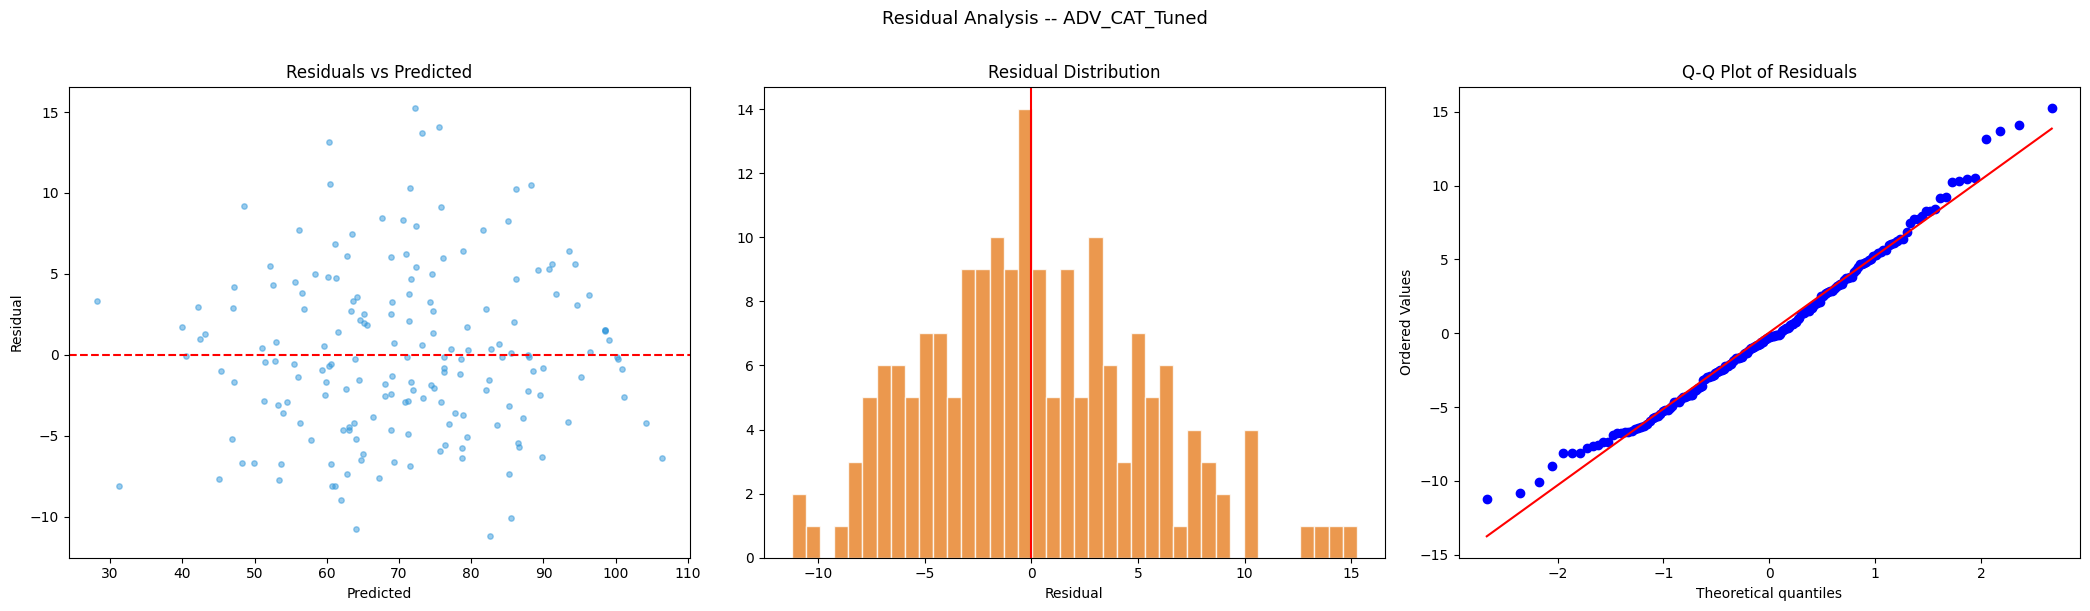

Near-zero centred residuals + straight Q-Q line = well-calibrated model.


In [32]:
# Phase 7.4 -- Residual analysis for best model
best_label = all_df.index[0]
best_preds = get_preds(best_label)
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

axes[0].scatter(best_preds, residuals, alpha=0.5, s=15, c="#3498DB")
axes[0].axhline(0, color="red", lw=1.5, linestyle="--")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, color="#E67E22", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", lw=1.5)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual")

from scipy.stats import probplot
probplot(residuals, plot=axes[2])
axes[2].set_title("Q-Q Plot of Residuals")

plt.suptitle(f"Residual Analysis -- {best_label}", fontsize=13, y=1.01)
plt.tight_layout()
savefig("residual_analysis", "models")
plt.show()
print("Near-zero centred residuals + straight Q-Q line = well-calibrated model.")


---
## Phase 8 -- Explainable AI (XAI)
### SHAP | Permutation Importance | Partial Dependence Plots


In [33]:
# Phase 8.1 -- SHAP TreeExplainer on tuned XGBoost
explainer   = shap.TreeExplainer(xgb_tuned)
shap_values = explainer(X_test_df)
shap_arr    = shap_values.values

print(f"SHAP values shape: {shap_arr.shape}")
print("SHAP explainer ready.")


SHAP values shape: (182, 22)
SHAP explainer ready.


  saved -> output_artifacts/xai/shap_bar_global.png


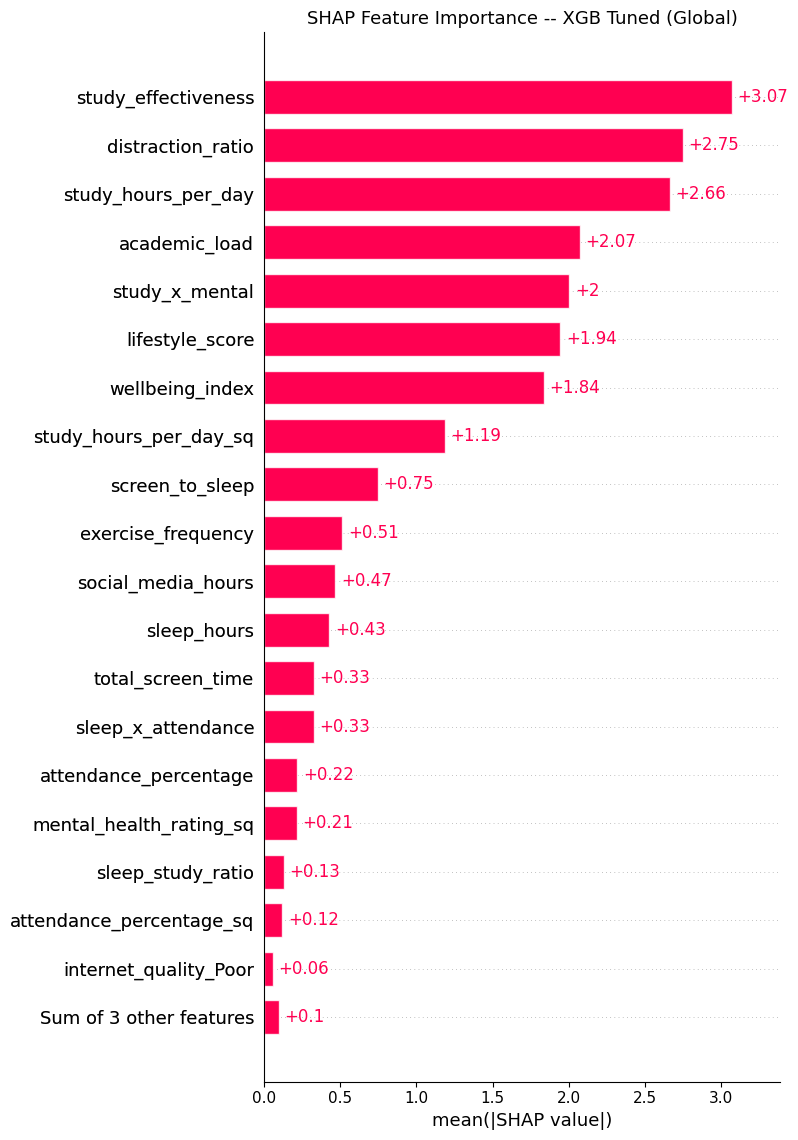

Mean |SHAP| ranks which features most influence ANY prediction on average.


In [34]:
# Phase 8.2 -- SHAP Bar Plot: global feature importance
plt.figure(figsize=(12, 7))
shap.plots.bar(shap_values, max_display=20, show=False)
plt.title("SHAP Feature Importance -- XGB Tuned (Global)", fontsize=13)
plt.tight_layout()
savefig("shap_bar_global", "xai")
plt.show()
print("Mean |SHAP| ranks which features most influence ANY prediction on average.")


  saved -> output_artifacts/xai/shap_beeswarm.png


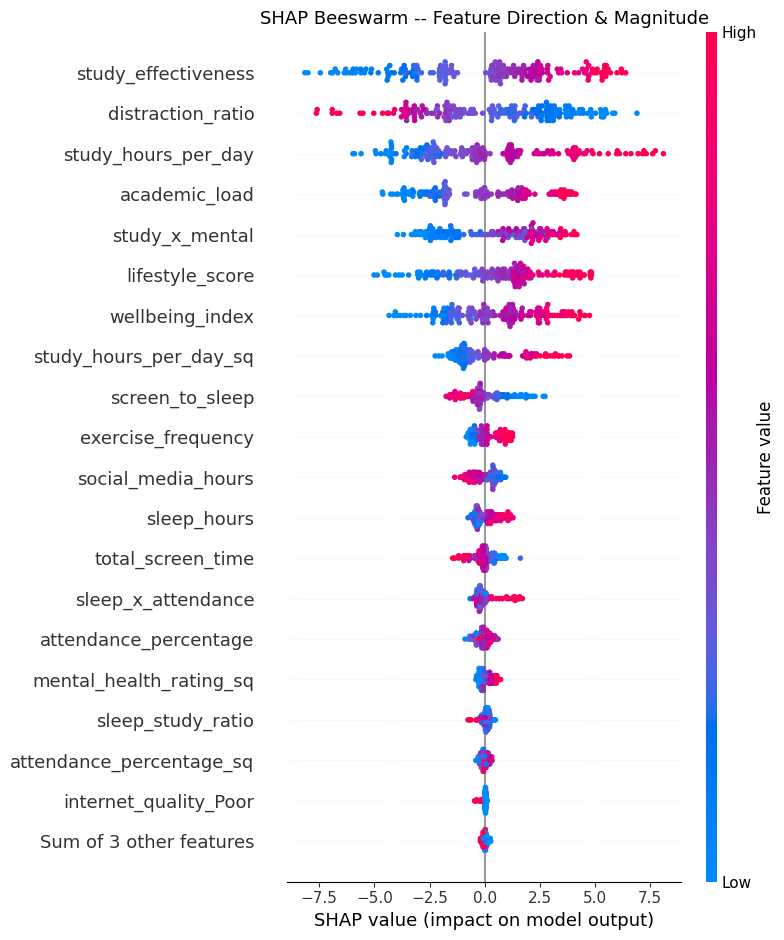

Color = feature value (red=high, blue=low). X-axis shows impact on prediction.
E.g. high study_hours (red) -> positive SHAP -> higher predicted score.


In [35]:
# Phase 8.3 -- SHAP Beeswarm: feature direction and magnitude
plt.figure(figsize=(13, 8))
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP Beeswarm -- Feature Direction & Magnitude", fontsize=13)
plt.tight_layout()
savefig("shap_beeswarm", "xai")
plt.show()
print("Color = feature value (red=high, blue=low). X-axis shows impact on prediction.")
print("E.g. high study_hours (red) -> positive SHAP -> higher predicted score.")


  saved -> output_artifacts/xai/shap_waterfall_student0.png


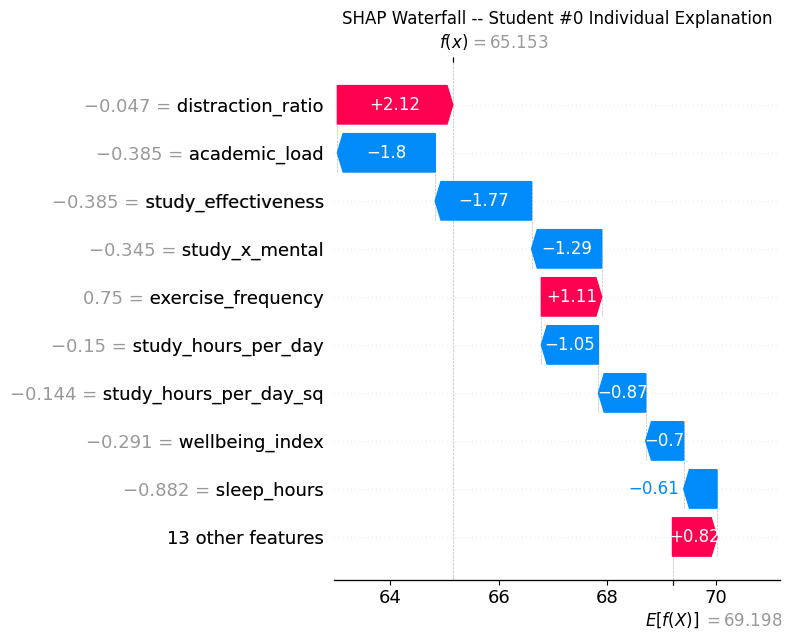

Actual score : 59.60
Predicted    : 65.15
The waterfall shows exactly WHY this student got that prediction.


In [36]:
# Phase 8.4 -- SHAP Waterfall for a single student (local explanation)
student_idx = 0
plt.figure(figsize=(13, 7))
shap.plots.waterfall(shap_values[student_idx], show=False)
plt.title(f"SHAP Waterfall -- Student #{student_idx} Individual Explanation", fontsize=12)
plt.tight_layout()
savefig("shap_waterfall_student0", "xai")
plt.show()

actual_score = y_test.values[student_idx]
pred_score   = float(xgb_tuned.predict(X_test_df.iloc[[student_idx]])[0])
print(f"Actual score : {actual_score:.2f}")
print(f"Predicted    : {pred_score:.2f}")
print("The waterfall shows exactly WHY this student got that prediction.")


  saved -> output_artifacts/xai/shap_dependence_top2.png


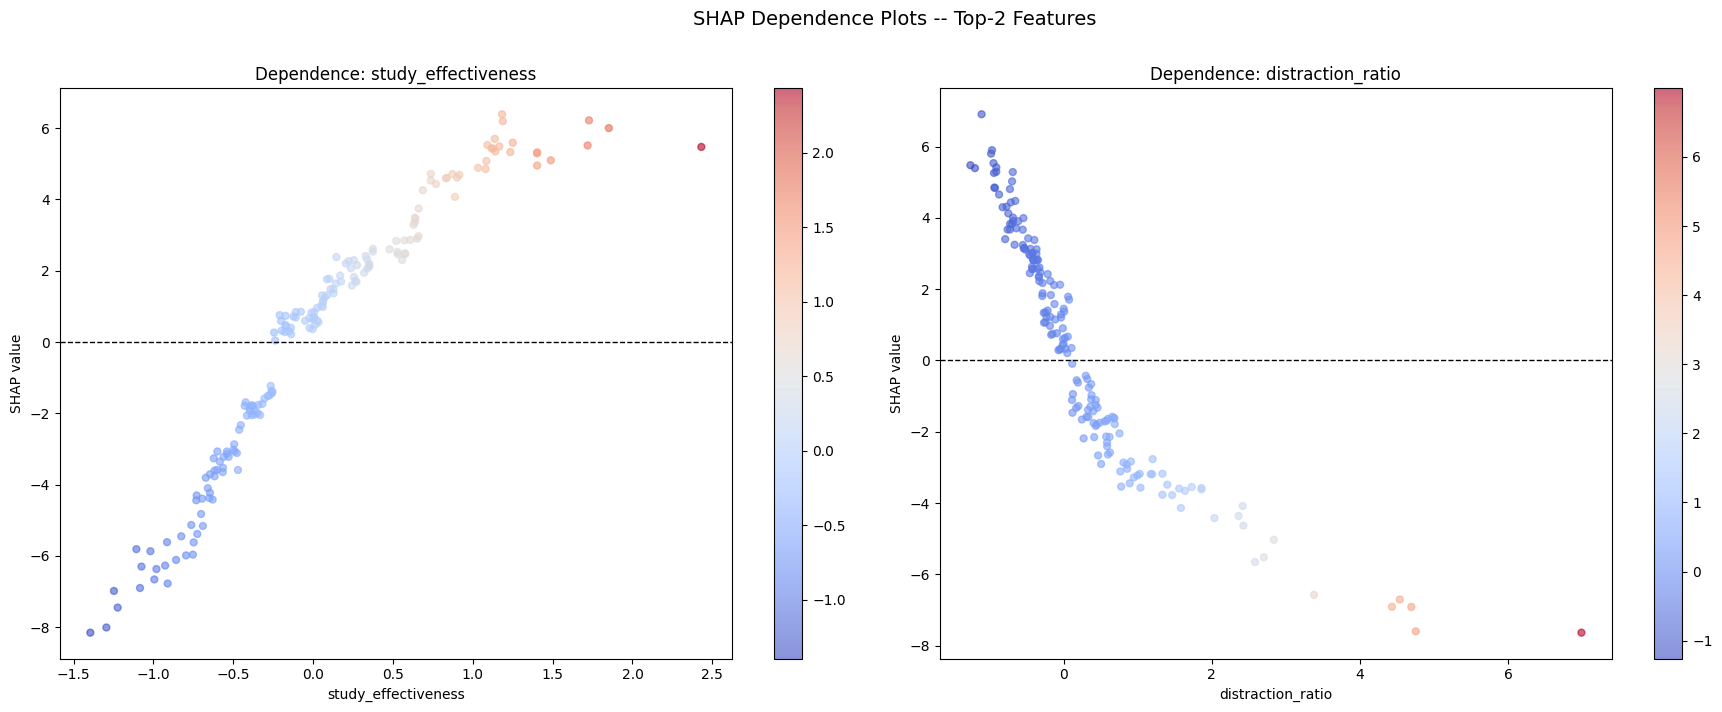

Non-linear SHAP curves confirm why tree models outperform linear ones.


In [37]:
# Phase 8.5 -- SHAP Dependence Plots for top-2 features
top_shap_features = pd.Series(np.abs(shap_arr).mean(axis=0),
                               index=SELECTED_FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, feat in zip(axes, top_shap_features.index[:2]):
    feat_vals = X_test_df[feat].values
    feat_shap = shap_arr[:, SELECTED_FEATURES.index(feat)]
    sc = ax.scatter(feat_vals, feat_shap, c=feat_vals, cmap="coolwarm", alpha=0.6, s=25)
    ax.axhline(0, color="black", lw=1, linestyle="--")
    ax.set_xlabel(feat)
    ax.set_ylabel("SHAP value")
    ax.set_title(f"Dependence: {feat}")
    plt.colorbar(sc, ax=ax)

plt.suptitle("SHAP Dependence Plots -- Top-2 Features", fontsize=14, y=1.01)
plt.tight_layout()
savefig("shap_dependence_top2", "xai")
plt.show()
print("Non-linear SHAP curves confirm why tree models outperform linear ones.")


  saved -> output_artifacts/xai/permutation_importance.png


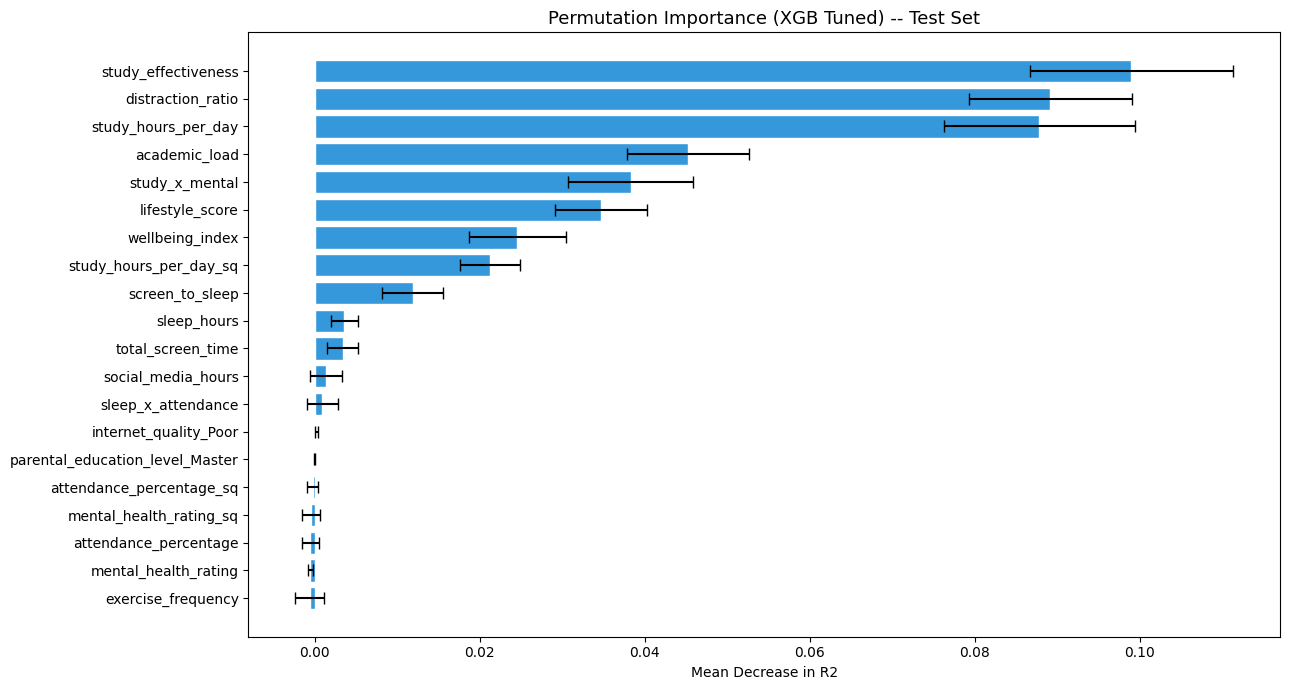

Permutation importance = drop in R2 when that feature is randomly shuffled.
Error bars = standard deviation across 20 shuffles.


In [38]:
# Phase 8.6 -- Permutation Importance (test-set drop in R2)
perm = permutation_importance(xgb_tuned, X_test_df, y_test,
                              n_repeats=20, random_state=42, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature"   : SELECTED_FEATURES,
    "importance": perm.importances_mean,
    "std"       : perm.importances_std,
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(13, 7))
plt.barh(perm_df["feature"], perm_df["importance"],
         xerr=perm_df["std"], color="#3498DB", edgecolor="white",
         error_kw={"ecolor": "black", "capsize": 4})
plt.xlabel("Mean Decrease in R2")
plt.title("Permutation Importance (XGB Tuned) -- Test Set", fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
savefig("permutation_importance", "xai")
plt.show()
print("Permutation importance = drop in R2 when that feature is randomly shuffled.")
print("Error bars = standard deviation across 20 shuffles.")


  saved -> output_artifacts/xai/partial_dependence_top3.png


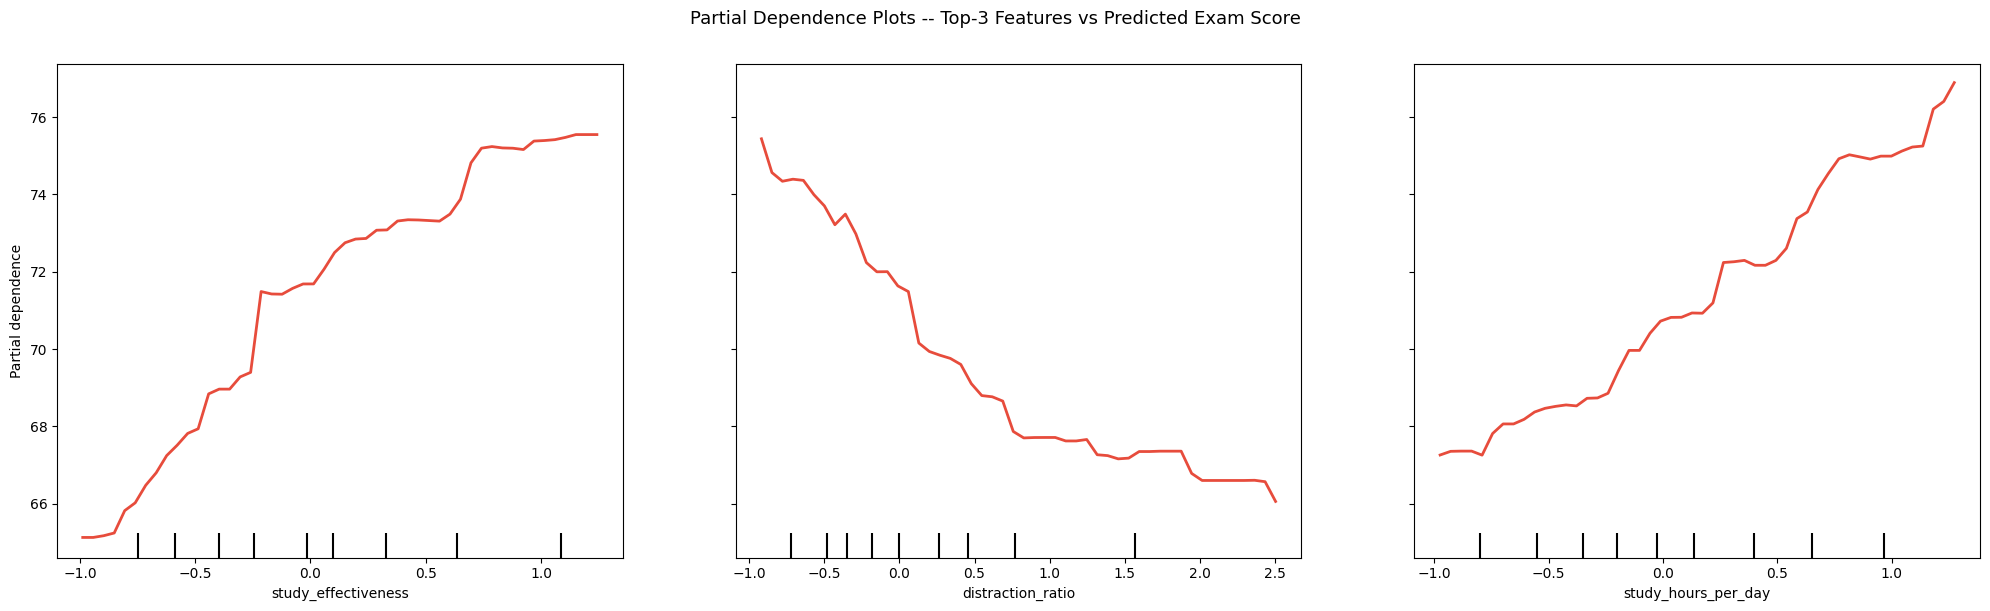

PDP shows the marginal effect of each feature, averaging out all others.
Non-linear curves = complex feature interactions present.


In [39]:
# Phase 8.7 -- Partial Dependence Plots for top-3 features
top3_feat_names = top_shap_features.index[:3].tolist()
top3_feat_idx   = [SELECTED_FEATURES.index(f) for f in top3_feat_names]

fig, ax = plt.subplots(figsize=(20, 6))
PartialDependenceDisplay.from_estimator(
    xgb_tuned, X_test_df, top3_feat_idx,
    feature_names=SELECTED_FEATURES,
    ax=ax, grid_resolution=50,
    line_kw={"color": "#E74C3C", "lw": 2},
)
plt.suptitle("Partial Dependence Plots -- Top-3 Features vs Predicted Exam Score",
             fontsize=13, y=1.01)
plt.tight_layout()
savefig("partial_dependence_top3", "xai")
plt.show()
print("PDP shows the marginal effect of each feature, averaging out all others.")
print("Non-linear curves = complex feature interactions present.")


---
## Phase 9 -- Export All Artifacts -> ZIP Download


In [40]:
# Phase 9.1 -- Save metrics tables to CSV
baseline_df.to_csv(OUT / "models" / "baseline_results.csv")
adv_df.to_csv(     OUT / "models" / "advanced_ml_results.csv")
dl_df.to_csv(      OUT / "models" / "dl_results.csv")
all_df.to_csv(     OUT / "models" / "all_models_comparison.csv")

# SHAP importance table
shap_importance = pd.DataFrame({
    "feature"    : SELECTED_FEATURES,
    "mean_abs_shap": np.abs(shap_arr).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)
shap_importance.to_csv(OUT / "xai" / "shap_feature_importance.csv", index=False)

print("All CSVs saved.")


All CSVs saved.


In [41]:
# Phase 9.2 -- Zip output folder and trigger download
zip_path = "student_performance_artifacts.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file_path in OUT.rglob("*"):
        if file_path.is_file():
            zf.write(file_path, file_path.relative_to(OUT.parent))

import os
size_mb = os.path.getsize(zip_path) / 1_048_576
print(f"ZIP created: {zip_path}  ({size_mb:.2f} MB)")

from google.colab import files
files.download(zip_path)
print("Download triggered -- check your browser downloads.")


ZIP created: student_performance_artifacts.zip  (3.60 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered -- check your browser downloads.


---
## Pipeline Complete

| Phase | Description |
|-------|-------------|
| 1 | Environment setup & data ingestion |
| 2 | Advanced EDA -- 9 annotated visuals with interpretations |
| 3 | Feature engineering -- 13 new features, MI selection |
| 4 | Baseline ML -- 9 models mirroring original notebook |
| 5 | Advanced ML -- Optuna tuning + stacking + voting ensembles |
| 6 | Deep Learning -- 4 architectures with EarlyStopping & ReduceLR |
| 7 | Full orchestration -- all models ranked in master comparison |
| 8 | XAI -- SHAP bar, beeswarm, waterfall, dependence, PDP, permutation |
| 9 | All plots + tables zipped & downloaded |

All outputs are saved inside `output_artifacts/` and packaged as a single downloadable ZIP.
